Published conference article: https://dl.acm.org/doi/10.1145/3459637.3481895

Google Colab: https://colab.research.google.com/drive/1g_smMt_-qQZyq5EaXBEo8XBu2KrvhDLI?usp=sharing

Webpage: https://emutivo.wpi.edu/index.php/publications/


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Define the epochs to process
epochs = [1,2,3,4,5,6,7,8]  # Extend this list if needed
training_loss = []
testing_loss = []
f1_scores = []

for epoch in epochs:
    file_path = f'/content/drive/MyDrive/AIED25/M4_Audibert/AFFECTIVE/results_epoch_{epoch}.pkl'
    data = pd.read_pickle(file_path)  # This is a list of dictionaries
    training_loss.append(data[0]['average training loss'])
    testing_loss.append(data[0]['average validation loss'])
    f1_scores.append(data[0]['f1'])

# Create two separate plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# Plot Average Training Loss
axes[0].plot(epochs, training_loss, 'o-', color='tab:red', label='Avg Training Loss')
axes[0].plot(epochs, testing_loss, 'x-', color='tab:green', label='Avg Validation Loss')
for x, y in zip(epochs, training_loss):
    axes[0].text(x, y, f'{y:.4f}', ha='right', va='bottom')
for x, y in zip(epochs, testing_loss):
    axes[0].text(x, y, f'{y:.4f}', ha='right', va='bottom')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
plt.title('Training and Validation Loss')
axes[0].grid(True)
axes[0].legend()
#axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# Plot F1 Score
axes[1].plot(epochs, f1_scores, 'o-', color='tab:blue', label='F1 Score')
for x, y in zip(epochs, f1_scores):
    axes[1].text(x, y, f'{y:.4f}', ha='right', va='bottom')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score over Epochs')
axes[1].grid(True)
axes[1].legend()
#axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

# Adjust layout and show plot
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AIED25/M4_Audibert/AFFECTIVE/results_epoch_1.pkl'

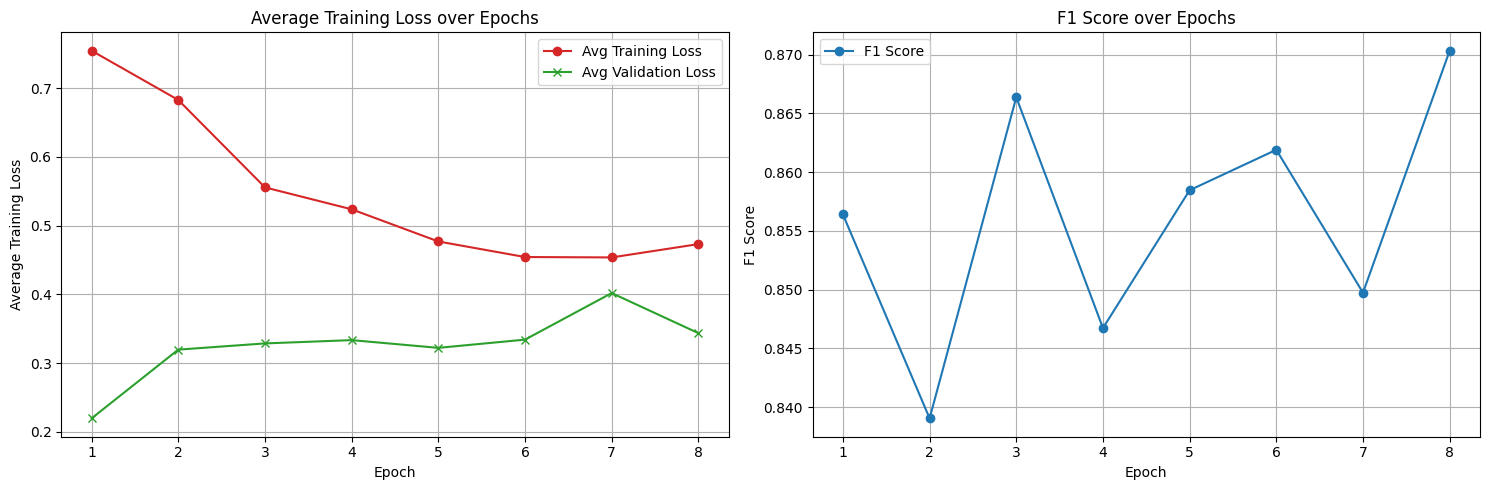

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Define the epochs to process
epochs = [1, 2, 3, 4, 5, 6, 7, 8]  # Extend this list if needed
tlosses = []
vlosses = []
f1_scores = []

for epoch in epochs:
    file_path = f'/content/drive/MyDrive/AIED25/M4_Audibert/AFFECTIVE/results_epoch_{epoch}.pkl'
    data = pd.read_pickle(file_path)  # This is a list of dictionaries
    tlosses.append(data[0]['average training loss'])
    vlosses.append(data[0]['average validation loss'])
    f1_scores.append(data[0]['f1'])

# Create two separate plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# Plot Average Training Loss
axes[0].plot(epochs, tlosses, 'o-', color='tab:red', label='Avg Training Loss')
axes[0].plot(epochs, vlosses, 'x-', color='tab:green', label='Avg Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average Training Loss')
axes[0].set_title('Average Training Loss over Epochs')
axes[0].grid(True)
axes[0].legend()
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# Plot F1 Score
axes[1].plot(epochs, f1_scores, 'o-', color='tab:blue', label='F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score over Epochs')
axes[1].grid(True)
axes[1].legend()
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

# Adjust layout and show plot
plt.tight_layout()
plt.show()


   epoch  average training loss  average validation loss  \
0      5                0.47698                  0.32228   

                                         true_labels  \
0  [0, 0, 0, 1, 1, 0, 2, 0, 2, 0, 1, 0, 0, 1, 1, ...   

                                         predictions  \
0  [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, ...   

                                    falseProbability  \
0  [23.09699821472168, 14.39720630645752, 17.4261...   

                                     trueProbability       mcc        f1  \
0  [-14.088641166687012, -13.252594947814941, -10...  0.720175  0.858465   

   precision    recall       acc  
0   0.860668  0.861224  0.861224  
Classification Report:
               precision    recall  f1-score   support

         AS1      0.800     0.889     0.842        90
         AS2      0.909     0.867     0.887       150
         AS3      0.500     0.200     0.286         5

   micro avg      0.861     0.861     0.861       245
   macro avg      0.7

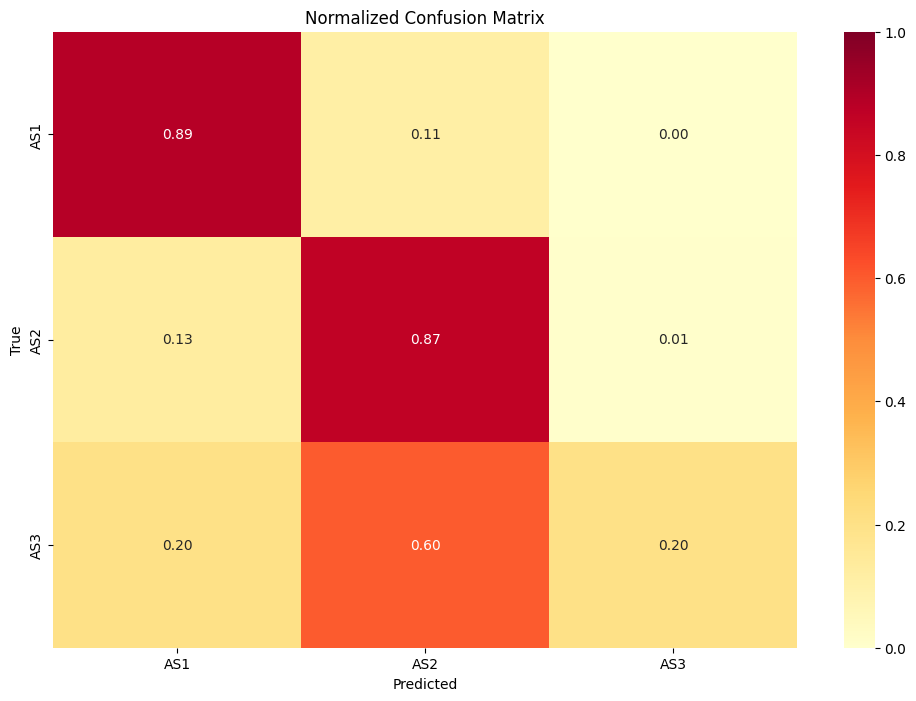

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/AFFECTIVE/results_epoch_5.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==5]
print(df)

# Label dictionary
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

   epoch average validation loss  \
0      3      [1.62376663709339]   

                                         true_labels  \
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, ...   

                                         predictions  \
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...   

                                    falseProbability  \
0  [-0.445841908454895, -1.3480992317199707, 0.10...   

                                     trueProbability     mcc        f1  \
0  [4.892431259155273, 6.644294738769531, 2.62870...  0.7794  0.889233   

   precision    recall       acc  
0   0.890082  0.888889  0.888889  
Classification Report:
               precision    recall  f1-score   support

         AS1      0.849     0.886     0.867       114
         AS2      0.922     0.897     0.909       184
         AS3      0.750     0.750     0.750         8

   micro avg      0.889     0.889     0.889       306
   macro avg      0.840     0.844     0.842       306
weighted avg      0

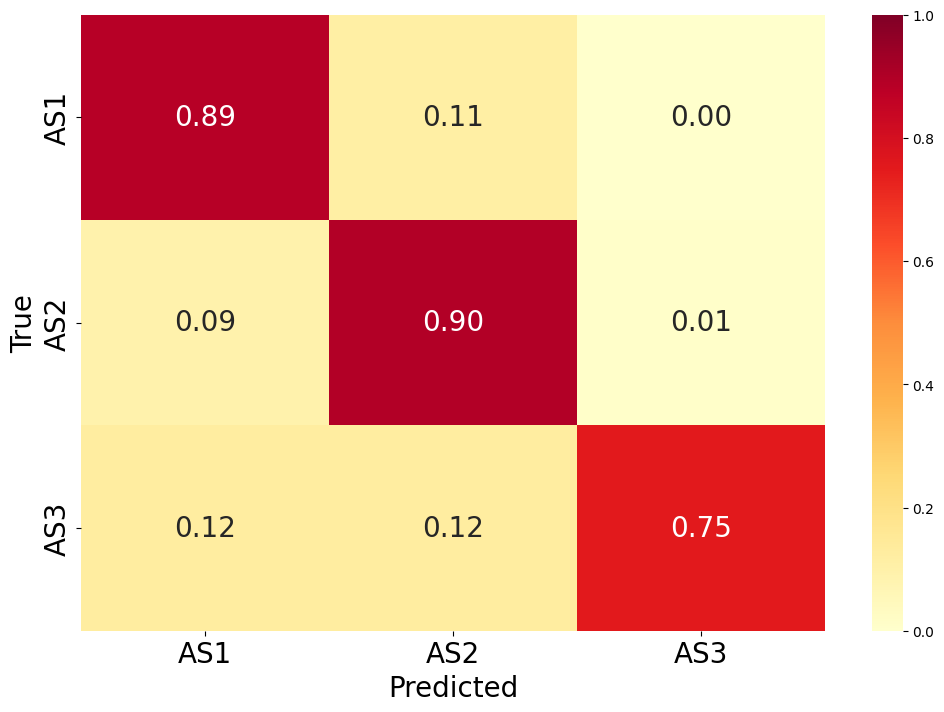

In [ ]:
#TEST HERE

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/AFFECTIVE_10Feb/testing_result_3.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==3]
print(df)

# Label dictionary
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
#             xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
#             vmin=0, vmax=1)
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Normalized Confusion Matrix')
# plt.show()

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 20}   # 🔥 numbers inside cells
)

ax.set_xlabel('Predicted', fontsize=20)
ax.set_ylabel('True', fontsize=20)
# ax.set_title('AudiBERT', fontsize=18)

# 🔥 tick labels
ax.tick_params(axis='both', labelsize=20)

# IMPORTANT: save the figure object
fig.savefig("/content/drive/MyDrive/AIED25/confusion_matrix_audibert_affective_bigger.pdf", bbox_inches="tight")

plt.show()

   epoch  average training loss  average validation loss  \
0      2               0.682726                 0.319719   

                                         true_labels  \
0  [0, 0, 0, 1, 1, 0, 2, 0, 2, 0, 1, 0, 0, 1, 1, ...   

                                         predictions  \
0  [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, ...   

                                    falseProbability  \
0  [18.67173194885254, 12.555586814880371, 15.601...   

                                     trueProbability       mcc        f1  \
0  [-11.470364570617676, -9.239767074584961, -11....  0.687441  0.839059   

   precision    recall       acc  
0   0.836397  0.844898  0.844898  
Classification Report:
               precision    recall  f1-score   support

         AS1      0.775     0.878     0.823        90
         AS2      0.901     0.853     0.877       150
         AS3      0.000     0.000     0.000         5

   micro avg      0.845     0.845     0.845       245
   macro avg      0.5

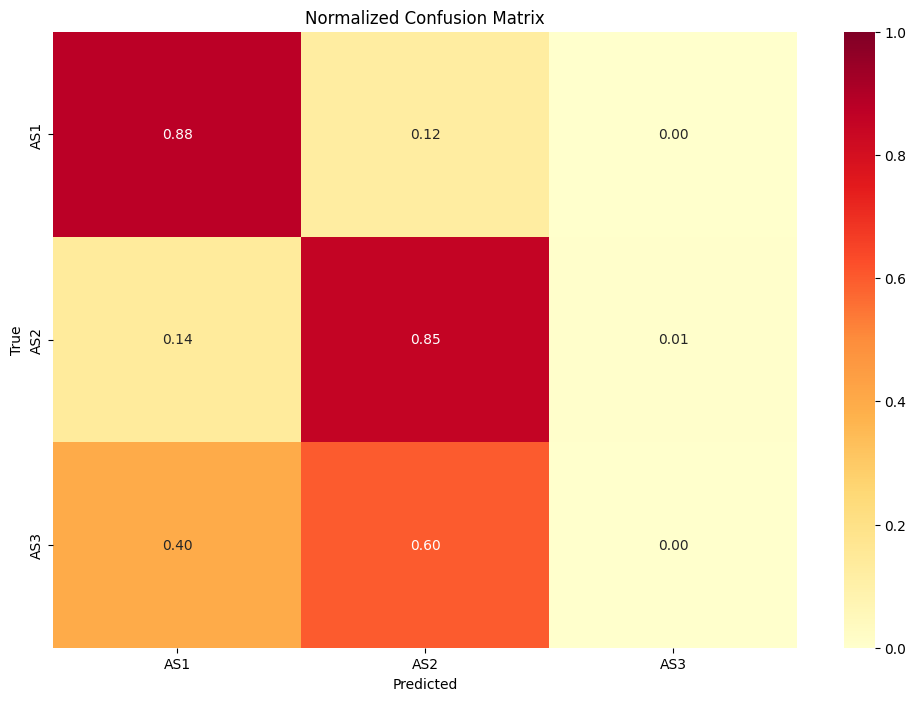

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/AFFECTIVE/results_epoch_2.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==2]
print(df)

# Label dictionary
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

   epoch  average training loss  average validation loss  \
0      3               0.555618                 0.328745   

                                         true_labels  \
0  [0, 0, 0, 1, 1, 0, 2, 0, 2, 0, 1, 0, 0, 1, 1, ...   

                                         predictions  \
0  [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, ...   

                                    falseProbability  \
0  [19.994112014770508, 10.799192428588867, 14.06...   

                                     trueProbability       mcc        f1  \
0  [-13.315770149230957, -11.259498596191406, -12...  0.734964  0.866374   

   precision    recall       acc  
0   0.867433  0.869388  0.869388  
Classification Report:
               precision    recall  f1-score   support

         AS1      0.816     0.889     0.851        90
         AS2      0.910     0.880     0.895       150
         AS3      0.500     0.200     0.286         5

   micro avg      0.869     0.869     0.869       245
   macro avg      0.7

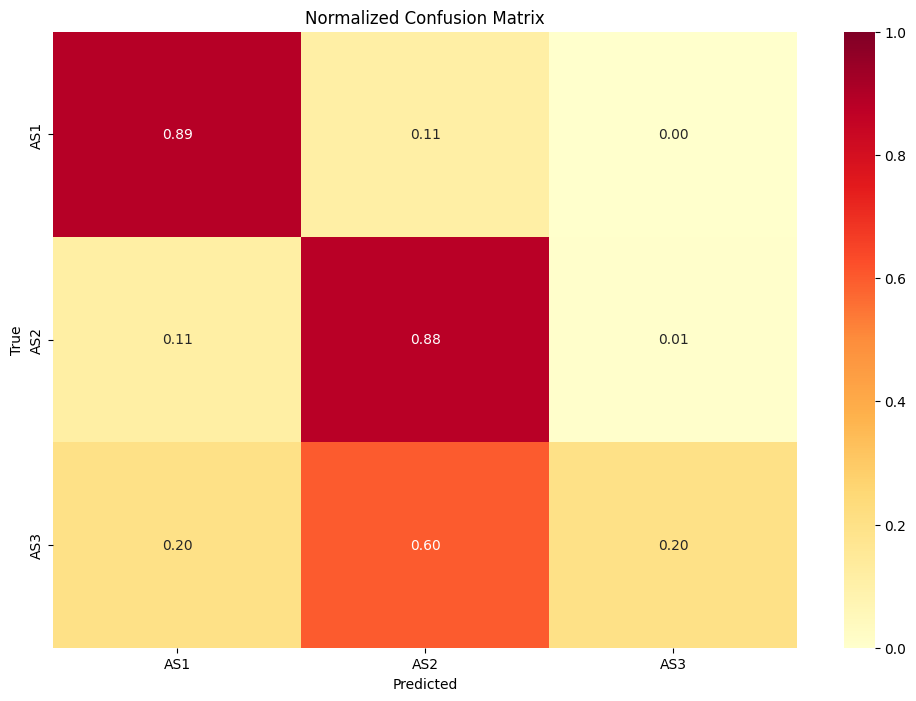

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/AFFECTIVE/results_epoch_3.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==3]
print(df)

# Label dictionary
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

   epoch  average training loss  average validation loss  \
0      4               0.523755                  0.33353   

                                         true_labels  \
0  [0, 0, 0, 1, 1, 0, 2, 0, 2, 0, 1, 0, 0, 1, 1, ...   

                                         predictions  \
0  [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, ...   

                                    falseProbability  \
0  [19.86408042907715, 14.292384147644043, 16.581...   

                                     trueProbability       mcc        f1  \
0  [-9.608760833740234, -10.477812767028809, -10....  0.700132  0.846739   

   precision    recall       acc  
0   0.841721  0.853061  0.853061  
Classification Report:
               precision    recall  f1-score   support

         AS1      0.796     0.867     0.830        90
         AS2      0.897     0.873     0.885       150
         AS3      0.000     0.000     0.000         5

   micro avg      0.853     0.853     0.853       245
   macro avg      0.5

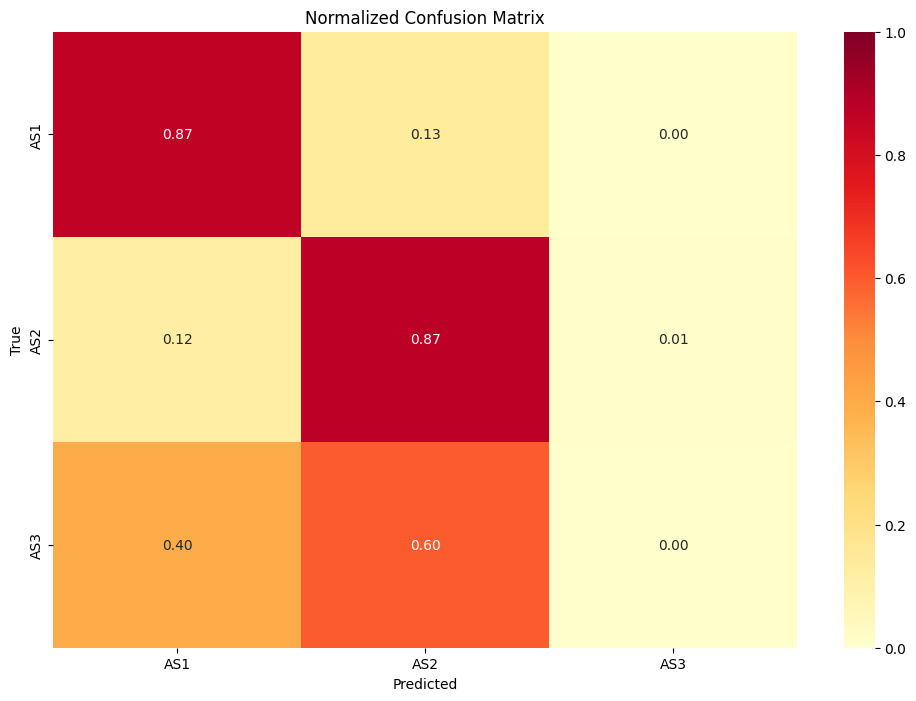

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/AFFECTIVE/results_epoch_4.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==4]
print(df)

# Label dictionary
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

   epoch  average training loss  \
0      5                0.66947   

                                         true_labels  \
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, ...   

                                         predictions  \
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, ...   

                                    falseProbability  \
0  [-6.7087788581848145, -9.326127052307129, -1.1...   

                                     trueProbability       mcc        f1  \
0  [18.03315544128418, 13.31804084777832, 8.83527...  0.754234  0.867866   

   precision    recall       acc  
0   0.892038  0.875817  0.875817  
Classification Report:
               precision    recall  f1-score   support

         AS1      0.977     0.737     0.840       114
         AS2      0.835     0.989     0.905       184
         AS3      1.000     0.250     0.400         8

   micro avg      0.876     0.876     0.876       306
   macro avg      0.937     0.659     0.715       306
weighted avg     

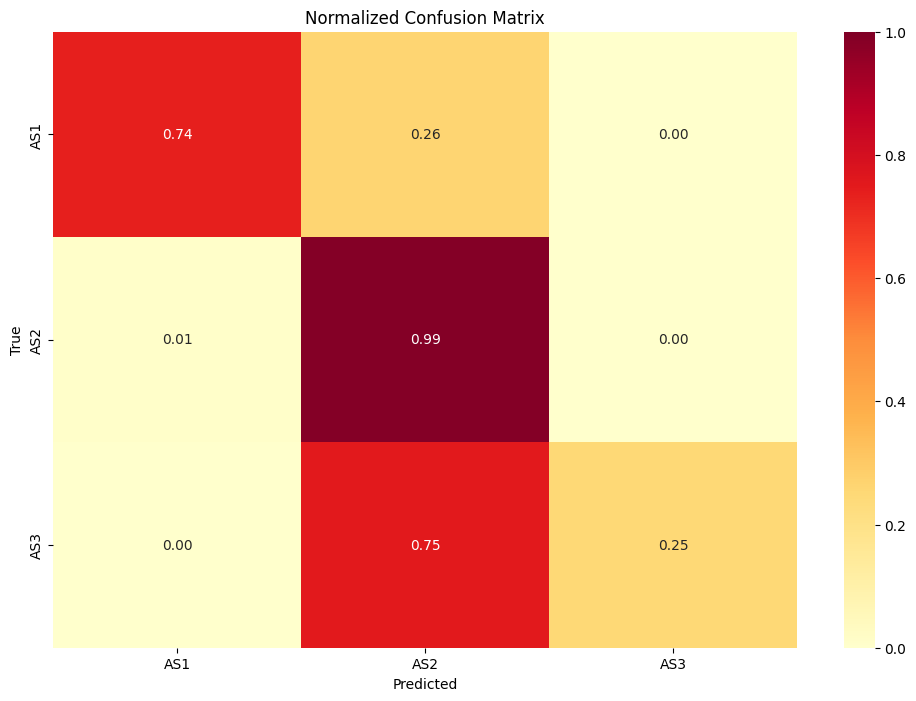

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/AFFECTIVE/results_epoch_5.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==5]
print(df)

# Label dictionary
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

   epoch  average training loss  \
0      1               1.926145   

                                         true_labels  \
0  [0, 8, 1, 1, 8, 8, 8, 1, 8, 9, 8, 1, 1, 2, 8, ...   

                                         predictions  \
0  [1, 8, 1, 1, 1, 1, 9, 1, 8, 9, 1, 1, 1, 1, 8, ...   

                                    falseProbability  \
0  [4.262833118438721, -0.24025262892246246, 0.31...   

                                     trueProbability       mcc        f1  \
0  [10.171290397644043, -3.912390947341919, 3.789...  0.408606  0.512239   

   precision    recall       acc  
0   0.484452  0.570175  0.570175  
Classification Report:
               precision    recall  f1-score   support

         SS1      0.000     0.000     0.000        43
         SS2      0.519     0.780     0.623       245
         SS3      0.125     0.014     0.026        70
         SS4      0.000     0.000     0.000         6
         SS5      0.333     0.053     0.091        19
         SS6      

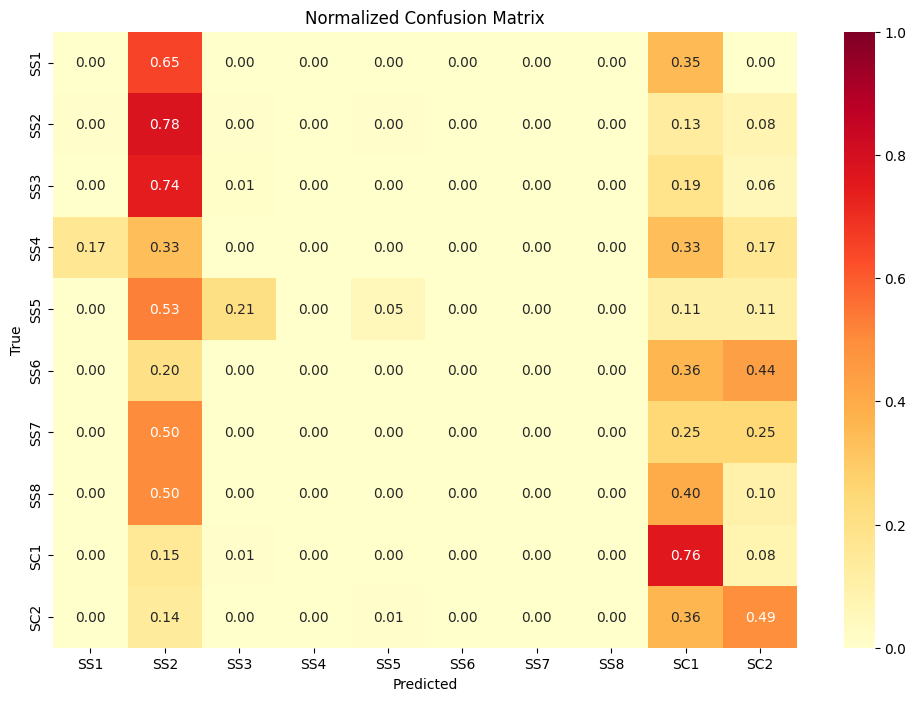

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/results.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==1]
print(df)

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

# CORRECTED AUDIBERT IMPROVED

1
Testing Loss: [0.7041921916120103]
F1 Scores: [0.4987352302093328]


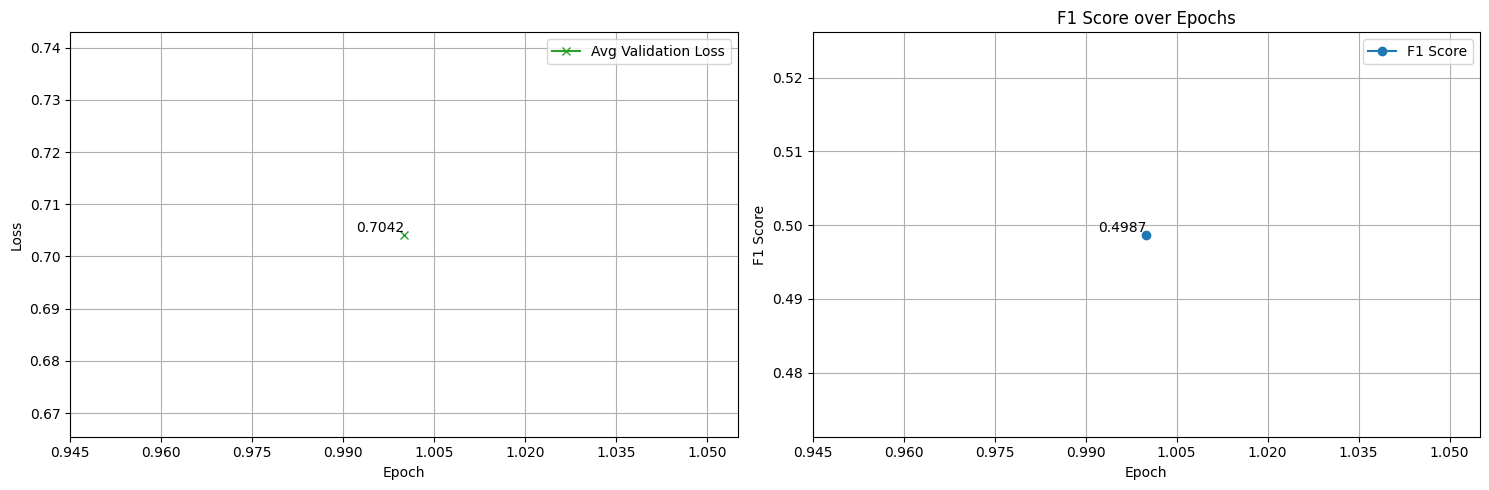

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Define the epochs to process
epochs = [1]  # Extend this list if needed
training_loss = []
testing_loss = []
f1_scores = []

for epoch in epochs:
    print(epoch)
    file_path = f'/content/drive/MyDrive/AIED25/M4_Audibert/testing_result_{epoch}.pkl'
    data = pd.read_pickle(file_path)  # This is a list of dictionaries
    df = pd.DataFrame(data)

    # Extract scalar values
    testing_loss.append(df['average validation loss'].iloc[0][0])
    f1_scores.append(df['f1'].iloc[0])

print("Testing Loss:", testing_loss)
print("F1 Scores:", f1_scores)


# Create two separate plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# Plot Average Training Loss
axes[0].plot(epochs, testing_loss, 'x-', color='tab:green', label='Avg Validation Loss')
for x, y in zip(epochs, training_loss):
    axes[0].text(x, y, f'{y:.4f}', ha='right', va='bottom')
for x, y in zip(epochs, testing_loss):
    axes[0].text(x, y, f'{y:.4f}', ha='right', va='bottom')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
plt.title('Training and Validation Loss')
axes[0].grid(True)
axes[0].legend()
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# Plot F1 Score
axes[1].plot(epochs, f1_scores, 'o-', color='tab:blue', label='F1 Score')
for x, y in zip(epochs, f1_scores):
    axes[1].text(x, y, f'{y:.4f}', ha='right', va='bottom')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score over Epochs')
axes[1].grid(True)
axes[1].legend()
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

# Adjust layout and show plot
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/testing_result_1.pkl')
print(data)

[{'epoch': 1, 'average validation loss': [0.7041921916120103], 'true_labels': [0, 8, 1, 1, 8, 8, 8, 1, 8, 9, 8, 1, 1, 2, 8, 3, 8, 9, 1, 8, 8, 2, 8, 9, 8, 2, 1, 0, 8, 0, 9, 2, 9, 7, 8, 9, 9, 1, 1, 2, 1, 8, 0, 8, 2, 9, 1, 1, 1, 1, 9, 1, 9, 2, 2, 8, 8, 1, 8, 9, 1, 1, 8, 9, 1, 4, 1, 9, 8, 1, 8, 0, 8, 9, 1, 9, 9, 9, 9, 8, 8, 9, 8, 7, 8, 1, 9, 9, 9, 8, 9, 8, 1, 2, 1, 9, 5, 2, 8, 4, 8, 9, 1, 2, 8, 0, 8, 2, 8, 1, 8, 8, 8, 1, 1, 9, 8, 2, 8, 9, 8, 1, 8, 8, 8, 8, 1, 2, 9, 8, 8, 8, 1, 9, 8, 9, 8, 9, 8, 8, 8, 9, 9, 9, 8, 1, 8, 8, 8, 9, 8, 0, 2, 0, 8, 8, 9, 8, 1, 8, 0, 8, 9, 8, 1, 8, 1, 1, 1, 0, 8, 1, 5, 8, 1, 8, 1, 1, 2, 1, 8, 9, 2, 8, 2, 7, 1, 1, 8, 1, 1, 1, 1, 0, 9, 0, 2, 8, 2, 9, 2, 1, 2, 9, 1, 8, 1, 0, 8, 1, 8, 1, 8, 9, 8, 9, 8, 8, 2, 1, 9, 9, 1, 8, 9, 5, 1, 0, 9, 8, 8, 8, 9, 1, 1, 9, 0, 8, 2, 8, 8, 9, 1, 3, 9, 8, 1, 9, 8, 1, 9, 8, 4, 1, 9, 1, 4, 8, 1, 4, 4, 0, 1, 8, 1, 8, 1, 8, 8, 5, 8, 1, 8, 1, 8, 9, 9, 2, 0, 8, 1, 1, 4, 2, 2, 2, 8, 1, 8, 8, 1, 1, 2, 8, 1, 2, 1, 4, 8, 1, 9, 8, 9, 1, 7, 1, 8, 

In [ ]:
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/results_epoch_1.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==2]
print(df)

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

Empty DataFrame
Columns: [epoch, average training loss, average validation loss, true_labels, predictions, falseProbability, trueProbability, mcc, f1, precision, recall, acc]
Index: []


ValueError: need at least one array to concatenate

   epoch                     average training loss  \
0      2  [1.9164740733769183, 2.0158650535319707]   

                    average validation loss  \
0  [0.5679551966766773, 0.5973408621293183]   

                                         true_labels  \
0  [9, 8, 2, 8, 1, 8, 8, 8, 2, 4, 8, 8, 8, 1, 1, ...   

                                         predictions  \
0  [9, 8, 2, 8, 1, 8, 8, 8, 8, 0, 8, 8, 8, 1, 8, ...   

                                    falseProbability  \
0  [0.37690237164497375, -1.1929937601089478, 2.8...   

                                     trueProbability      mcc       f1  \
0  [-1.5349465608596802, 2.461834192276001, 2.287...  0.42146  0.52583   

   precision    recall       acc  
0   0.527683  0.572016  0.572016  
Classification Report:
               precision    recall  f1-score   support

         SS1      0.167     0.030     0.051        33
         SS2      0.551     0.781     0.647       192
         SS3      0.500     0.269     0.350        

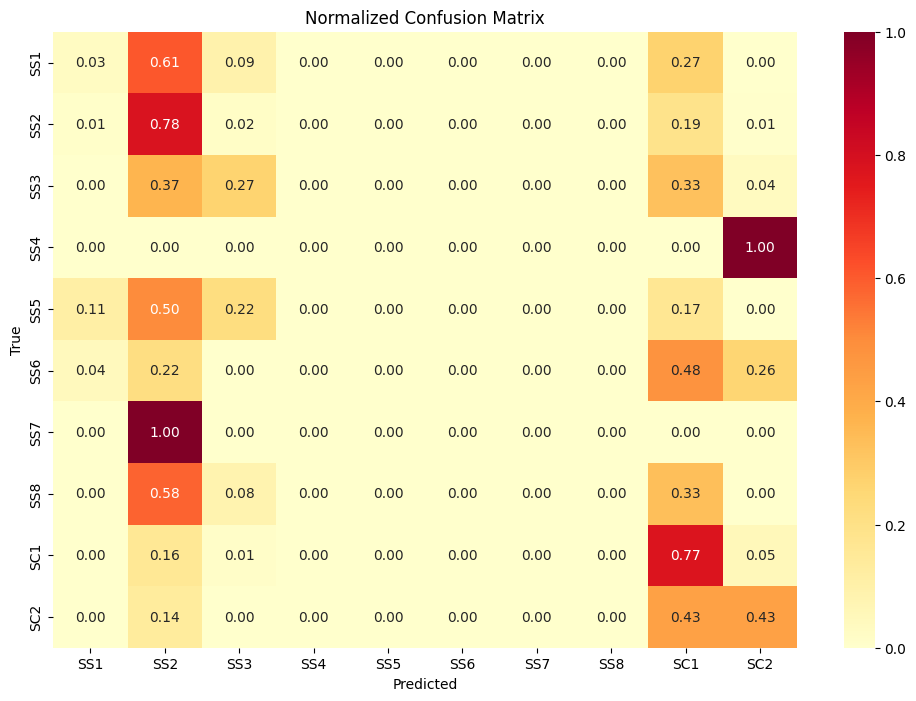

In [ ]:
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/results_epoch_2.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==2]
print(df)

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

#1.9164740733769183
#2.0158650535319707
#1.924375548962305

In [ ]:
file_path = f'/content/drive/MyDrive/AIED25/M4_Audibert/results_epoch_2.pkl'
data = pd.read_pickle(file_path)  # This is a list of dictionaries
print(data)
print(data['average training loss'])
print(data['average validation loss'])

   epoch average training loss average validation loss  \
0      2  [2.0158650535319707]    [0.5973408621293183]   

                                         true_labels  \
0  [9, 8, 2, 8, 1, 8, 8, 8, 2, 4, 8, 8, 8, 1, 1, ...   

                                         predictions  \
0  [9, 8, 2, 8, 1, 8, 8, 8, 8, 0, 8, 8, 8, 1, 8, ...   

                                    falseProbability  \
0  [0.37690237164497375, -1.1929937601089478, 2.8...   

                                     trueProbability      mcc       f1  \
0  [-1.5349465608596802, 2.461834192276001, 2.287...  0.42146  0.52583   

   precision    recall       acc  
0   0.527683  0.572016  0.572016  
0    [2.0158650535319707]
Name: average training loss, dtype: object
0    [0.5973408621293183]
Name: average validation loss, dtype: object


In [ ]:
file_path = f'/content/drive/MyDrive/AIED25/M4_Audibert/results_epoch_2.pkl'
data = pd.read_pickle(file_path)  # This is a list of dictionaries
print(data)
print(data[0]['average training loss'][1])
data[0]['average training loss'] = [data[0]['average training loss'][1]]
print(data[0]['average training loss'])
print(data[0]['average validation loss'][1])
data[0]['average validation loss'] = [data[0]['average validation loss'][1]]
print(data[0]['average validation loss'])

df.to_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/results_epoch_2a.pkl')

[{'epoch': 2, 'average training loss': [1.9164740733769183, 2.0158650535319707], 'average validation loss': [0.5679551966766773, 0.5973408621293183], 'true_labels': [9, 8, 2, 8, 1, 8, 8, 8, 2, 4, 8, 8, 8, 1, 1, 1, 1, 8, 8, 1, 0, 8, 9, 8, 8, 8, 2, 1, 2, 8, 1, 1, 1, 8, 1, 3, 0, 8, 1, 9, 2, 2, 1, 8, 1, 1, 1, 8, 2, 9, 0, 2, 2, 9, 5, 7, 1, 1, 2, 8, 8, 8, 0, 5, 2, 1, 1, 0, 8, 8, 8, 1, 8, 1, 1, 9, 8, 1, 8, 9, 4, 0, 1, 8, 7, 6, 1, 1, 8, 1, 2, 8, 1, 8, 2, 1, 5, 9, 1, 9, 8, 8, 9, 9, 1, 1, 8, 8, 8, 1, 8, 8, 8, 9, 9, 8, 8, 1, 4, 8, 8, 8, 8, 9, 9, 9, 9, 8, 5, 1, 1, 1, 1, 9, 9, 9, 2, 8, 9, 1, 8, 8, 8, 1, 1, 8, 1, 9, 1, 2, 0, 9, 9, 9, 9, 5, 1, 9, 8, 9, 1, 8, 2, 7, 1, 8, 8, 2, 8, 9, 2, 8, 9, 8, 0, 9, 2, 8, 1, 8, 8, 1, 1, 9, 2, 4, 9, 9, 9, 9, 8, 0, 8, 9, 0, 9, 1, 8, 8, 1, 2, 9, 9, 8, 8, 9, 9, 2, 9, 8, 1, 1, 8, 9, 8, 9, 8, 8, 8, 2, 1, 1, 9, 8, 9, 5, 8, 8, 5, 1, 1, 2, 9, 8, 1, 1, 5, 4, 5, 1, 8, 8, 8, 8, 1, 2, 0, 9, 7, 0, 0, 1, 9, 7, 8, 4, 2, 1, 8, 1, 1, 8, 5, 8, 8, 1, 8, 1, 1, 2, 2, 9, 8, 1, 7, 1, 1, 8, 

In [ ]:
print(data)

[{'epoch': 2, 'average training loss': [2.0158650535319707], 'average validation loss': [0.5973408621293183], 'true_labels': [9, 8, 2, 8, 1, 8, 8, 8, 2, 4, 8, 8, 8, 1, 1, 1, 1, 8, 8, 1, 0, 8, 9, 8, 8, 8, 2, 1, 2, 8, 1, 1, 1, 8, 1, 3, 0, 8, 1, 9, 2, 2, 1, 8, 1, 1, 1, 8, 2, 9, 0, 2, 2, 9, 5, 7, 1, 1, 2, 8, 8, 8, 0, 5, 2, 1, 1, 0, 8, 8, 8, 1, 8, 1, 1, 9, 8, 1, 8, 9, 4, 0, 1, 8, 7, 6, 1, 1, 8, 1, 2, 8, 1, 8, 2, 1, 5, 9, 1, 9, 8, 8, 9, 9, 1, 1, 8, 8, 8, 1, 8, 8, 8, 9, 9, 8, 8, 1, 4, 8, 8, 8, 8, 9, 9, 9, 9, 8, 5, 1, 1, 1, 1, 9, 9, 9, 2, 8, 9, 1, 8, 8, 8, 1, 1, 8, 1, 9, 1, 2, 0, 9, 9, 9, 9, 5, 1, 9, 8, 9, 1, 8, 2, 7, 1, 8, 8, 2, 8, 9, 2, 8, 9, 8, 0, 9, 2, 8, 1, 8, 8, 1, 1, 9, 2, 4, 9, 9, 9, 9, 8, 0, 8, 9, 0, 9, 1, 8, 8, 1, 2, 9, 9, 8, 8, 9, 9, 2, 9, 8, 1, 1, 8, 9, 8, 9, 8, 8, 8, 2, 1, 1, 9, 8, 9, 5, 8, 8, 5, 1, 1, 2, 9, 8, 1, 1, 5, 4, 5, 1, 8, 8, 8, 8, 1, 2, 0, 9, 7, 0, 0, 1, 9, 7, 8, 4, 2, 1, 8, 1, 1, 8, 5, 8, 8, 1, 8, 1, 1, 2, 2, 9, 8, 1, 7, 1, 1, 8, 9, 1, 9, 9, 8, 8, 8, 1, 1, 1, 2, 8, 1, 8

In [ ]:
df = pd.DataFrame(data)
print(df)

   epoch average training loss average validation loss  \
0      2  [2.0158650535319707]    [0.5973408621293183]   

                                         true_labels  \
0  [9, 8, 2, 8, 1, 8, 8, 8, 2, 4, 8, 8, 8, 1, 1, ...   

                                         predictions  \
0  [9, 8, 2, 8, 1, 8, 8, 8, 8, 0, 8, 8, 8, 1, 8, ...   

                                    falseProbability  \
0  [0.37690237164497375, -1.1929937601089478, 2.8...   

                                     trueProbability      mcc       f1  \
0  [-1.5349465608596802, 2.461834192276001, 2.287...  0.42146  0.52583   

   precision    recall       acc  
0   0.527683  0.572016  0.572016  


In [ ]:
training_loss

[1.9164740733769183]

# Epoch 1: M4_Audibert_preloadBERT, Used in AIED25; testing_result_1.pkl

   epoch average validation loss  \
0      1     [4.491027205089669]   

                                         true_labels  \
0  [0, 8, 1, 1, 8, 8, 8, 1, 8, 9, 8, 1, 1, 2, 8, ...   

                                         predictions  \
0  [1, 8, 8, 2, 9, 0, 9, 1, 8, 9, 1, 1, 2, 1, 8, ...   

                                    falseProbability  \
0  [8.330280303955078, 3.1877248287200928, 5.6285...   

                                     trueProbability       mcc        f1  \
0  [18.455158233642578, -5.503743648529053, 5.830...  0.462369  0.586942   

   precision    recall       acc  
0   0.586522  0.597588  0.597588  
Classification Report:
               precision    recall  f1-score   support

         SS1      0.263     0.233     0.247        43
         SS2      0.584     0.669     0.624       245
         SS3      0.316     0.343     0.329        70
         SS4      1.000     0.167     0.286         6
         SS5      0.533     0.421     0.471        19
         SS6    

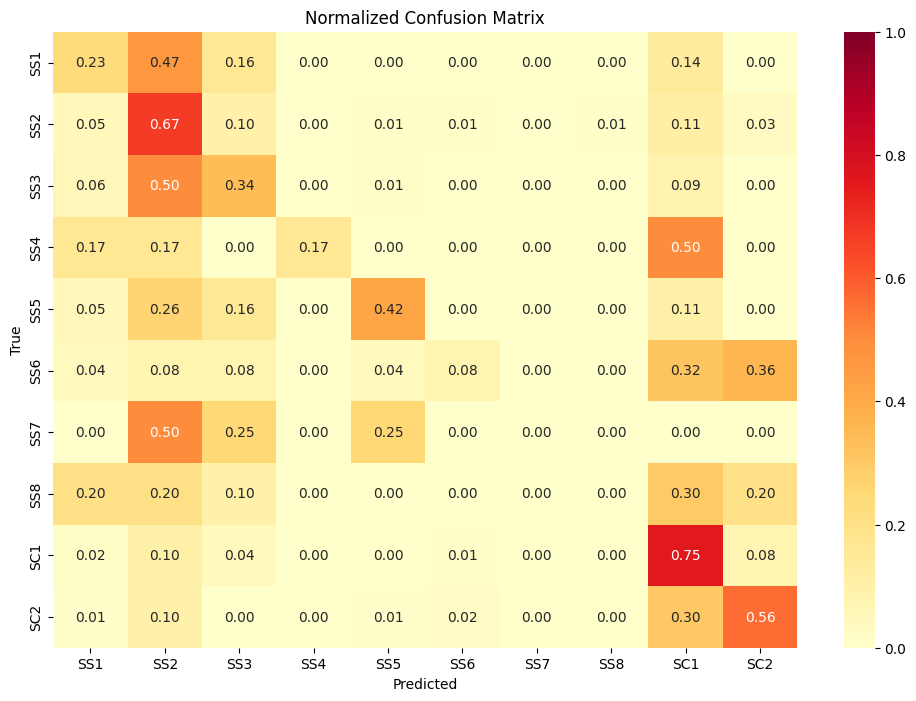

In [ ]:
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert_preloadBERT/testing_result_1.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==1]
print(df)

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

   epoch average validation loss  \
0      1     [4.491027205089669]   

                                         true_labels  \
0  [0, 8, 1, 1, 8, 8, 8, 1, 8, 9, 8, 1, 1, 2, 8, ...   

                                         predictions  \
0  [1, 8, 8, 2, 9, 0, 9, 1, 8, 9, 1, 1, 2, 1, 8, ...   

                                    falseProbability  \
0  [8.330280303955078, 3.1877248287200928, 5.6285...   

                                     trueProbability       mcc        f1  \
0  [18.455158233642578, -5.503743648529053, 5.830...  0.462369  0.586942   

   precision    recall       acc  
0   0.586522  0.597588  0.597588  
Classification Report:
               precision    recall  f1-score   support

         SS1      0.263     0.233     0.247        43
         SS2      0.584     0.669     0.624       245
         SS3      0.316     0.343     0.329        70
         SS4      1.000     0.167     0.286         6
         SS5      0.533     0.421     0.471        19
         SS6    

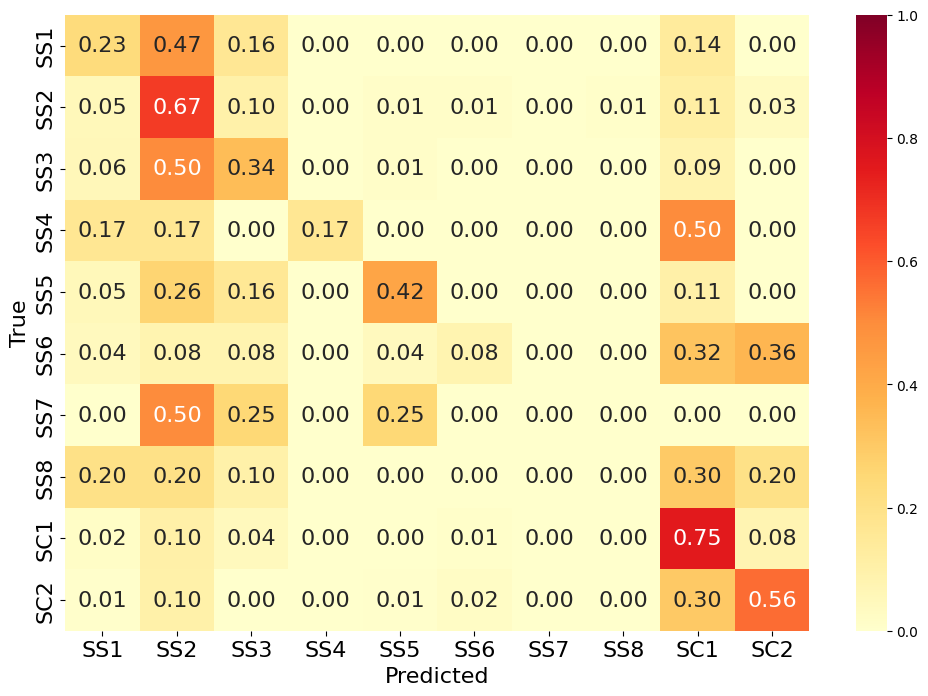

In [ ]:
#TEST HERE


%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert_preloadBERT/testing_result_1.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==1]
print(df)

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
#             xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
#             vmin=0, vmax=1)
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Normalized Confusion Matrix')
# plt.show()


fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 16}   # 🔥 numbers inside cells
)

ax.set_xlabel('Predicted', fontsize=16)
ax.set_ylabel('True', fontsize=16)
# ax.set_title('AudiBERT', fontsize=18)

# 🔥 tick labels
ax.tick_params(axis='both', labelsize=16)

# IMPORTANT: save the figure object
fig.savefig("/content/drive/MyDrive/AIED25/confusion_matrix_audibert_bigger.pdf", bbox_inches="tight")

plt.show()

# Epoch 1: M4_Audibert_preloadBERT, Used in Diagnosis analysis for PhD; testing_result_1.pkl

In [ ]:
data = pd.read_pickle('/content/drive/MyDrive/AIED25/Diagnosis_dataset/testing_result_1.pkl')
df = pd.DataFrame(data)

In [ ]:
df

,epoch,average validation loss,true_labels,predictions,falseProbability,trueProbability,mcc,f1,precision,recall,acc
0,1,[1.9873989179680376],"[9, 9, 9, 8, 8, 8, 8, 8, 9, 9, 1, 1, 1, 0, 1, ...","[9, 9, 5, 8, 1, 8, 8, 8, 8, 9, 1, 8, 1, 0, 1, ...","[-15.869708061218262, -11.336240768432617, -6....","[-5.049461841583252, -3.6498184204101562, -6.3...",0.702002,0.776379,0.789499,0.776923,0.776923


   epoch average validation loss  \
0      1    [1.9873989179680376]   

                                         true_labels  \
0  [9, 9, 9, 8, 8, 8, 8, 8, 9, 9, 1, 1, 1, 0, 1, ...   

                                         predictions  \
0  [9, 9, 5, 8, 1, 8, 8, 8, 8, 9, 1, 8, 1, 0, 1, ...   

                                    falseProbability  \
0  [-15.869708061218262, -11.336240768432617, -6....   

                                     trueProbability       mcc        f1  \
0  [-5.049461841583252, -3.6498184204101562, -6.3...  0.702002  0.776379   

   precision    recall       acc  
0   0.789499  0.776923  0.776923  
Classification Report:
               precision    recall  f1-score   support

         SS1      0.643     0.450     0.529        20
         SS2      0.887     0.870     0.879        54
         SS3      0.722     0.684     0.703        19
         SS4      0.000     0.000     0.000         0
         SS5      0.000     0.000     0.000         0
         SS6    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipython-input-3582969967.py:47: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


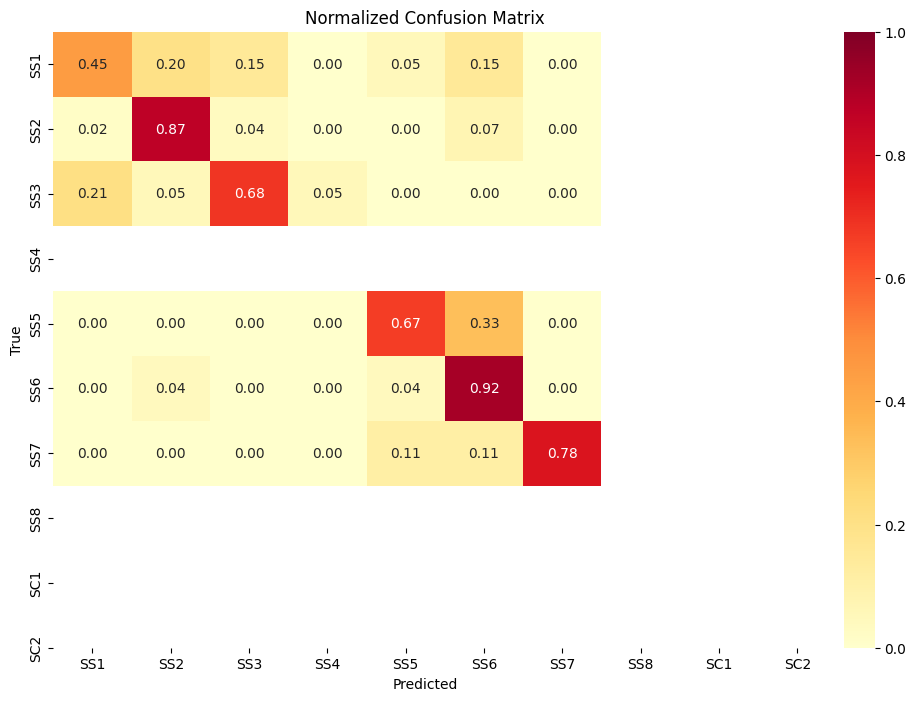

In [ ]:
%reset -f
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/Diagnosis_dataset/testing_result_1.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==1]
print(df)

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

# Create a DataFrame with one column
df = pd.DataFrame(predictions, columns=['predictions'])

# File path where the pickle file will be saved
file_path = '/content/drive/MyDrive/AIED25/Diagnosis_dataset/df_withAudiBERTprediction_PS_SC.pkl'
# Saving the metrics to a pickle file
with open(file_path, 'wb') as f:
    pickle.dump(df, f)

df = pd.read_pickle('/content/drive/MyDrive/AIED25/Diagnosis_dataset/df_withAudiBERTprediction_PS_SC.pkl')
df.to_excel('/content/drive/MyDrive/AIED25/Diagnosis_dataset/df_withAudiBERTprediction_PS_SC.xlsx', index=False)

In [ ]:
# Convert to list of rows
lines = report.strip().split("\n")[2:-4]  # Skip the header row and the average rows

# Extracting the values
data = []
for line in lines:
    values = line.split()
    if len(values) == 5:  # Ensure we're only processing valid rows with the expected number of elements
        label = values[0]
        precision, recall, f1_score, support = map(float, values[1:])
        data.append([label, precision, recall, f1_score, int(support)])

# Convert to DataFrame
reportdf1 = pd.DataFrame(data, columns=["Label", "Precision", "Recall", "F1-Score", "Support"])

# Display the DataFrame
print(reportdf1)

  Label  Precision  Recall  F1-Score  Support
0   SS1      0.000   0.000     0.000       43
1   SS2      0.550   0.759     0.638      245
2   SS3      0.400   0.143     0.211       70
3   SS4      0.000   0.000     0.000        6
4   SS5      0.500   0.158     0.240       19
5   SS6      0.000   0.000     0.000       25
6   SS7      0.000   0.000     0.000        4
7   SS8      0.000   0.000     0.000       10
8   SC1      0.622   0.818     0.707      318
9   SC2      0.683   0.477     0.562      172


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-4-e535d505ac23>:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We reco

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Classification Report:
               precision    recall  f1-score   support

         SS1      0.000     0.000     0.000        43
         SS2      0.599     0.641     0.619       245
         SS3      0.266     0.243     0.254        70
         SS4      0.000     0.000     0.000         6
         SS5      0.500     0.105     0.174        19
         SS6      0.000     0.000     0.000        25
         SS7      0.000     0.000     0.000         4
         SS8      0.000     0.000     0.000        10
         SC1      0.633     0.777     0.698       318
         SC2      0.583     0.651     0.615       172

   micro avg      0.587     0.587     0.587       912
   macro avg      0.258     0.242     0.236       912
weighted avg      0.523     0.587     0.549       912
 samples avg      0.587     0.587     0.587       912

Accuracy: 0.587
Precision: 0.523
Recall: 0.587
F1 Score: 0.549



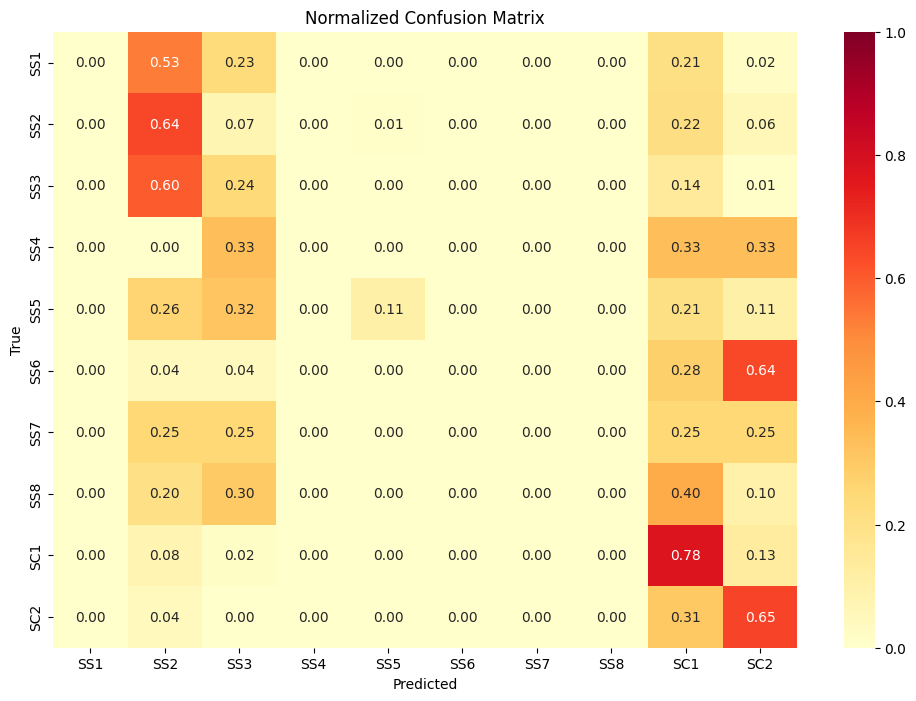

  Label  Precision  Recall  F1-Score  Support
0   SS1      0.000   0.000     0.000       43
1   SS2      0.599   0.641     0.619      245
2   SS3      0.266   0.243     0.254       70
3   SS4      0.000   0.000     0.000        6
4   SS5      0.500   0.105     0.174       19
5   SS6      0.000   0.000     0.000       25
6   SS7      0.000   0.000     0.000        4
7   SS8      0.000   0.000     0.000       10
8   SC1      0.633   0.777     0.698      318
9   SC2      0.583   0.651     0.615      172


In [ ]:
%reset -f
import numpy as np
import pandas as pd
import time
import datetime
import random
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler,random_split

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

import transformers
from transformers import BertForSequenceClassification, AdamW, BertConfig,BertTokenizer,get_linear_schedule_with_warmup

import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

# Load BertForSequenceClassification, the pretrained BERT model with a single
# linear classification layer on top.
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", # Use the 12-layer BERT model, with an uncased vocab.
    num_labels = 10, # The number of output labels--2 for binary classification.
                    # You can increase this for multi-class tasks.
    output_attentions = False, # Whether the model returns attentions weights.
    output_hidden_states = False, # Whether the model returns all hidden-states.
)

# if device == "cuda:0":
# # Tell pytorch to run this model on the GPU.
#     model = model.cuda()
model = model.to(device)

# (A) Select model based on highest average accuracy value
#model = torch.load('bert_model')

# (B) Manual selection of model by inspecting average training loss, average validation loss and average accuracy value in spreadsheet
model.load_state_dict(torch.load('/content/drive/MyDrive/AIED25/M2_BERT/PS_S_EPOCH/categories_BERT_epoch_2.model', map_location=torch.device('cpu')))

df = pd.read_pickle('/content/drive/MyDrive/AIED25/dataset/PS_S_df_test_df.pkl')
df['Utterance'] = df['Utterance'].astype(str)

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

batch_size = 32

test_input_ids = []
test_attention_masks = []
for utterance in df['Utterance']:
    encoded_dict = tokenizer.encode_plus(
                        utterance,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        padding= 'max_length',
                        max_length=128,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )
    test_input_ids.append(encoded_dict['input_ids'])
    test_attention_masks.append(encoded_dict['attention_mask'])
test_input_ids = torch.cat(test_input_ids, dim=0)
test_attention_masks = torch.cat(test_attention_masks, dim=0)

test_dataset = TensorDataset(test_input_ids, test_attention_masks)
test_dataloader = DataLoader(
            test_dataset, # The validation samples.
            sampler = SequentialSampler(test_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

predictions = []
for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        with torch.no_grad():
            output= model(b_input_ids,
                                   token_type_ids=None,
                                   attention_mask=b_input_mask)
            logits = output.logits
            logits = logits.detach().cpu().numpy()
            pred_flat = np.argmax(logits, axis=1).flatten()

            predictions.extend(list(pred_flat))

df['target'] = predictions
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

true_vals = df["label"].values  # True labels from df
predictions = df["target"].values  # Predicted labels from df

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

# Convert to list of rows
lines = report.strip().split("\n")[2:-4]  # Skip the header row and the average rows

# Extracting the values
data = []
for line in lines:
    values = line.split()
    if len(values) == 5:  # Ensure we're only processing valid rows with the expected number of elements
        label = values[0]
        precision, recall, f1_score, support = map(float, values[1:])
        data.append([label, precision, recall, f1_score, int(support)])

# Convert to DataFrame
reportBERT = pd.DataFrame(data, columns=["Label", "Precision", "Recall", "F1-Score", "Support"])

# Display the DataFrame
print(reportBERT)

Reading '/content/drive/MyDrive/AIED25/M1_RF_TFIDF/PS_S_df_train_df_grid_search_details.csv'
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

         SS1      1.000     0.023     0.045        43
         SS2      0.502     0.588     0.541       245
         SS3      0.273     0.043     0.074        70
         SS4      0.000     0.000     0.000         6
         SS5      0.500     0.053     0.095        19
         SS6      0.000     0.000     0.000        25
         SS7      0.000     0.000     0.000         4
         SS8      0.000     0.000     0.000        10
         SC1      0.525     0.830     0.643       318
         SC2      0.625     0.378     0.471       172

   micro avg      0.524     0.524     0.524       912
   macro avg      0.342     0.191     0.187       912
weighted avg      0.514     0.524     0.468       912
 samples avg      0.524     0.524     0.524       912

Accuracy: 0.524
Precision: 0.514
Recall: 0.524
F1 Score: 0.468



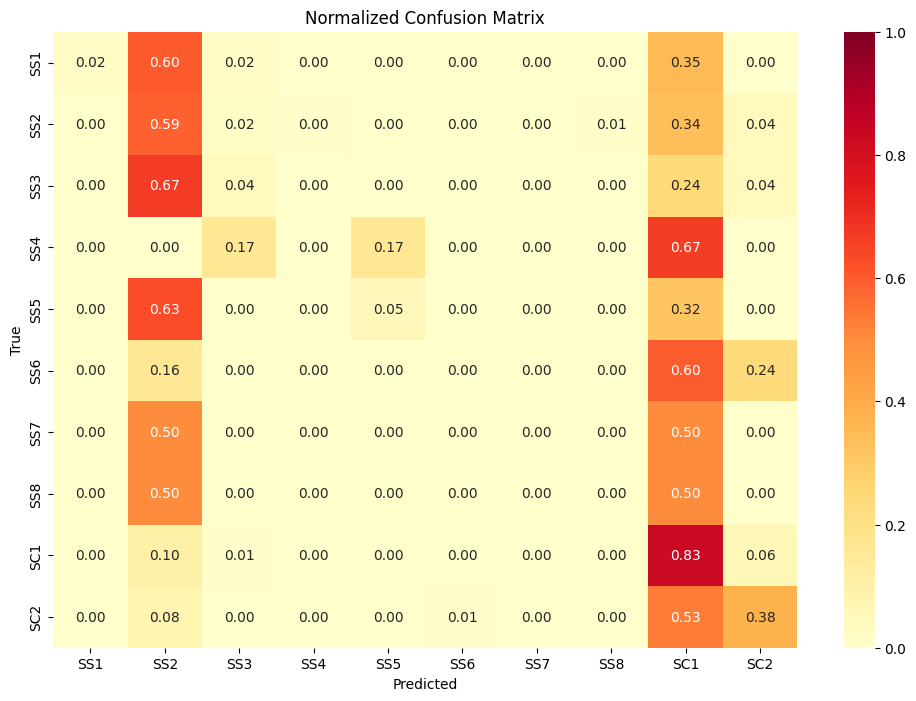

AUROC for SS1: 0.832
AUROC for SS2: 0.776
AUROC for SS3: 0.754
AUROC for SS4: 0.740
AUROC for SS5: 0.878
AUROC for SS6: 0.674
AUROC for SS7: 0.760
AUROC for SS8: 0.734
AUROC for SC1: 0.810
AUROC for SC2: 0.815
Weighted AUROC: 0.795
Per-class accuracy for SS1: 0.954
Per-class accuracy for SS2: 0.732
Per-class accuracy for SS3: 0.918
Per-class accuracy for SS4: 0.992
Per-class accuracy for SS5: 0.979
Per-class accuracy for SS6: 0.971
Per-class accuracy for SS7: 0.996
Per-class accuracy for SS8: 0.987
Per-class accuracy for SC1: 0.679
Per-class accuracy for SC2: 0.840
  Label  Precision  Recall  F1-Score  Support
0   SS1      1.000   0.023     0.045       43
1   SS2      0.502   0.588     0.541      245
2   SS3      0.273   0.043     0.074       70
3   SS4      0.000   0.000     0.000        6
4   SS5      0.500   0.053     0.095       19
5   SS6      0.000   0.000     0.000       25
6   SS7      0.000   0.000     0.000        4
7   SS8      0.000   0.000     0.000       10
8   SC1      0

In [ ]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

train_df = pd.read_pickle('/content/drive/MyDrive/AIED25/dataset/PS_S_df_train_df.pkl')
test_df = pd.read_pickle('/content/drive/MyDrive/AIED25/dataset/PS_S_df_test_df.pkl')

label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Reload the grid search results
results_df = pd.read_csv('/content/drive/MyDrive/AIED25/M1_RF_TFIDF/PS_S_df_train_df_grid_search_details.csv')
print("Reading '/content/drive/MyDrive/AIED25/M1_RF_TFIDF/PS_S_df_train_df_grid_search_details.csv'")
# Get the best row based on rank_test_score
best_row = results_df.loc[results_df['rank_test_score'].idxmin()]
# Extract parameters and clean up the 'param_' prefix
best_params = {col.replace('param_', ''): best_row[col] for col in results_df.columns if col.startswith('param_')}
# Convert NaN to None in the extracted parameters
best_params = {k: (None if pd.isna(v) else v) for k, v in best_params.items()}
best_params['max_depth'] = int(best_params['max_depth']) if best_params['max_depth'] is not None else None
print("Best Parameters:", best_params)

X_train = np.vstack(train_df['TFIDF Vector'].values)
y_train = train_df['label']
X_test = np.vstack(test_df['TFIDF Vector'].values)
y_test = test_df['label']

# Initialize the Random Forest Classifier with the best parameters
rf_classifier = RandomForestClassifier(**best_params, random_state=42)

# Train the classifier on the training data
rf_classifier.fit(X_train, y_train)

# Predict on the test data
y_pred = rf_classifier.predict(X_test)
y_prob = rf_classifier.predict_proba(X_test)  # Required for AUROC calculation

# Function to calculate accuracy per class using class labels (y_pred)
def accuracy_per_class(preds, labels):
    label_dict_inverse = {v: k for k, v in label_dict.items()}

    # Ensure preds and labels are NumPy arrays, convert if they're Pandas Series
    if isinstance(preds, pd.Series):
        preds = preds.to_numpy()
    if isinstance(labels, pd.Series):
        labels = labels.to_numpy()

    # Ensure preds and labels are 1D arrays
    preds_flat = preds.flatten()
    labels_flat = labels.flatten()

    for label in np.unique(labels_flat):
        y_preds = preds_flat[labels_flat == label]
        y_true = labels_flat[labels_flat == label]
        accuracy = np.sum(y_preds == label) / len(y_true) * 100 if len(y_true) > 0 else 0
        print(f'Class: {label_dict_inverse[label]}')
        print(f'Accuracy: {len(y_preds[y_preds == label])}/{len(y_true)} = {accuracy:.1f}% \n')


# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(y_test, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(y_pred, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')

# Print the classification report and confusion matrix
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')
cm = confusion_matrix(y_test, y_pred)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

# Calculate AUROC for each class
auroc_per_class = {}
for i, label in enumerate(label_dict.keys()):
    class_auroc = roc_auc_score(y_true_binarized[:, i], y_prob[:, i])
    auroc_per_class[label] = class_auroc
    print(f"AUROC for {label}: {class_auroc:.3f}")

# Calculate the weighted AUROC
class_counts = np.bincount(y_test)
class_weights = class_counts / len(y_test)
weighted_auroc = np.sum([class_weights[i] * auroc_per_class[label] for i, label in enumerate(label_dict.keys())])

print(f"Weighted AUROC: {weighted_auroc:.3f}")

# Function to calculate per-class accuracy
def per_class_accuracy(cm):
    # True Positives (TP): Diagonal elements of the confusion matrix
    TP = np.diag(cm)

    # False Positives (FP): Column-wise sum minus True Positives
    FP = np.sum(cm, axis=0) - TP

    # False Negatives (FN): Row-wise sum minus True Positives
    FN = np.sum(cm, axis=1) - TP

    # True Negatives (TN): Total sum of the confusion matrix minus TP, FP, and FN
    TN = np.sum(cm) - (FP + FN + TP)

    # Per-class accuracy: (TP + TN) / Total instances
    per_class_acc = (TP + TN) / np.sum(cm)

    return per_class_acc


# Calculate and display per-class accuracy
per_class_acc = per_class_accuracy(cm)
for i, label in enumerate(label_dict.keys()):
    # Use the label dictionary to print the class name along with its accuracy
    print(f"Per-class accuracy for {label}: {per_class_acc[i]:.3f}")

# Convert to list of rows
lines = report.strip().split("\n")[2:-4]  # Skip the header row and the average rows

# Extracting the values
data = []
for line in lines:
    values = line.split()
    if len(values) == 5:  # Ensure we're only processing valid rows with the expected number of elements
        label = values[0]
        precision, recall, f1_score, support = map(float, values[1:])
        data.append([label, precision, recall, f1_score, int(support)])

# Convert to DataFrame
reportrf_tfidf = pd.DataFrame(data, columns=["Label", "Precision", "Recall", "F1-Score", "Support"])

# Display the DataFrame
print(reportrf_tfidf)

In [ ]:
import pandas as pd
from scipy import stats

print("RF on TFIDF")
print(reportrf_tfidf)

print("BERT")
print(reportBERT)
# Merge the two DataFrames on the 'Label' column to align the precision values
merged_df = pd.merge(reportrf_tfidf[['Label', 'F1-Score']], reportBERT[['Label', 'F1-Score']], on='Label', suffixes=('_rf_tfidf', '_BERT'))

# Perform the paired t-test on the precision values
t_stat, p_value = stats.ttest_rel(merged_df['F1-Score_BERT'], merged_df['F1-Score_rf_tfidf'])

# Output the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Determine if the result is statistically significant
if p_value < 0.05:
    print("The difference in F1-Score is statistically significant.")
else:
    print("The difference in F1-Score is not statistically significant.")

RF on TFIDF
  Label  Precision  Recall  F1-Score  Support
0   SS1      1.000   0.023     0.045       43
1   SS2      0.502   0.588     0.541      245
2   SS3      0.273   0.043     0.074       70
3   SS4      0.000   0.000     0.000        6
4   SS5      0.500   0.053     0.095       19
5   SS6      0.000   0.000     0.000       25
6   SS7      0.000   0.000     0.000        4
7   SS8      0.000   0.000     0.000       10
8   SC1      0.525   0.830     0.643      318
9   SC2      0.625   0.378     0.471      172
BERT
  Label  Precision  Recall  F1-Score  Support
0   SS1      0.000   0.000     0.000       43
1   SS2      0.599   0.641     0.619      245
2   SS3      0.266   0.243     0.254       70
3   SS4      0.000   0.000     0.000        6
4   SS5      0.500   0.105     0.174       19
5   SS6      0.000   0.000     0.000       25
6   SS7      0.000   0.000     0.000        4
7   SS8      0.000   0.000     0.000       10
8   SC1      0.633   0.777     0.698      318
9   SC2      0.58

In [ ]:
import pandas as pd
from scipy import stats

print("AUDIBERT")
print(reportdf1)

print("BERT")
print(reportdf2)
# Merge the two DataFrames on the 'Label' column to align the precision values
merged_df = pd.merge(reportdf1[['Label', 'F1-Score']], reportdf2[['Label', 'F1-Score']], on='Label', suffixes=('_df1', '_df2'))

# Perform the paired t-test on the precision values
t_stat, p_value = stats.ttest_rel(merged_df['F1-Score_df2'], merged_df['F1-Score_df1'])

# Output the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Determine if the result is statistically significant
if p_value < 0.05:
    print("The difference in F1-Score is statistically significant.")
else:
    print("The difference in F1-Score is not statistically significant.")

AUDIBERT
  Label  Precision  Recall  F1-Score  Support
0   SS1      0.000   0.000     0.000       43
1   SS2      0.550   0.759     0.638      245
2   SS3      0.400   0.143     0.211       70
3   SS4      0.000   0.000     0.000        6
4   SS5      0.500   0.158     0.240       19
5   SS6      0.000   0.000     0.000       25
6   SS7      0.000   0.000     0.000        4
7   SS8      0.000   0.000     0.000       10
8   SC1      0.622   0.818     0.707      318
9   SC2      0.683   0.477     0.562      172
BERT
  Label  Precision  Recall  F1-Score  Support
0   SS1      0.000   0.000     0.000       43
1   SS2      0.550   0.784     0.646      245
2   SS3      0.227   0.214     0.221       70
3   SS4      0.000   0.000     0.000        6
4   SS5      0.600   0.158     0.250       19
5   SS6      0.000   0.000     0.000       25
6   SS7      0.000   0.000     0.000        4
7   SS8      0.000   0.000     0.000       10
8   SC1      0.706   0.664     0.684      318
9   SC2      0.605  

In [ ]:
for epoch in epochs:
    file_path = f'/content/drive/MyDrive/AIED25/M4_Audibert/results_epoch_{epoch}.pkl'
    data = pd.read_pickle(file_path)  # This is a list of dictionaries
    print(data[0]['f1'])

NameError: name 'epochs' is not defined

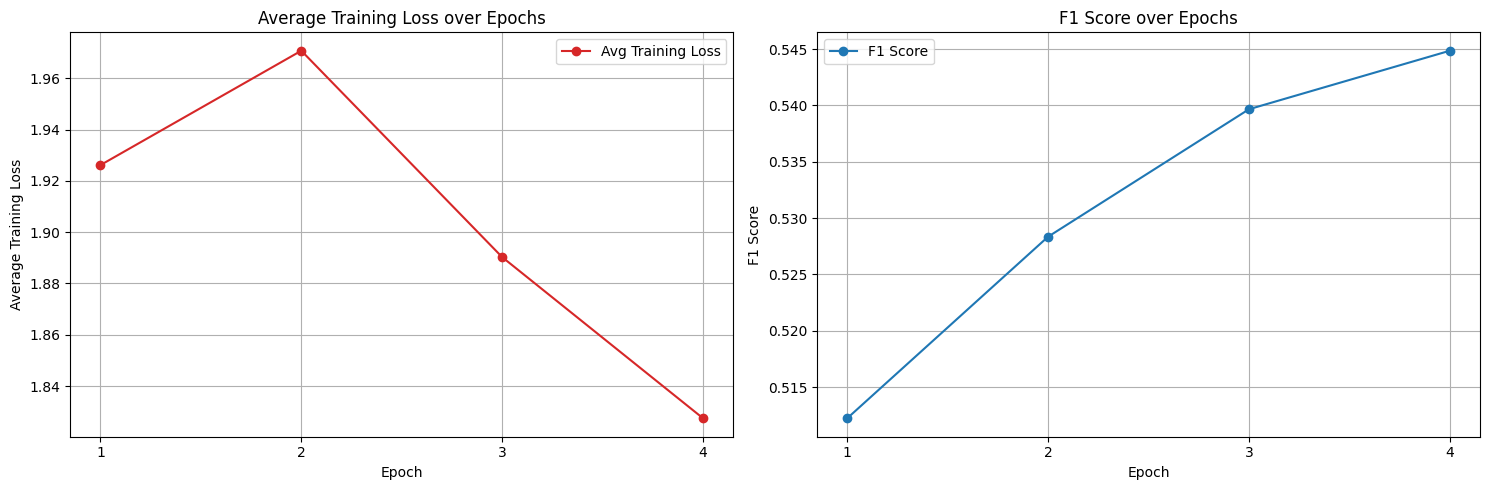

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Define the epochs to process
epochs = [1, 2, 3, 4]  # Extend this list if needed
losses = []
f1_scores = []

for epoch in epochs:
    file_path = f'/content/drive/MyDrive/AIED25/M4_Audibert/results_epoch_{epoch}.pkl'
    data = pd.read_pickle(file_path)  # This is a list of dictionaries
    losses.append(data[0]['average training loss'])
    f1_scores.append(data[0]['f1'])

# Create two separate plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# Plot Average Training Loss
axes[0].plot(epochs, losses, 'o-', color='tab:red', label='Avg Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average Training Loss')
axes[0].set_title('Average Training Loss over Epochs')
axes[0].grid(True)
axes[0].legend()
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# Plot F1 Score
axes[1].plot(epochs, f1_scores, 'o-', color='tab:blue', label='F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score over Epochs')
axes[1].grid(True)
axes[1].legend()
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

# Adjust layout and show plot
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/AIED25/M4_Audibert/results_epoch_1.pkl'
data = pd.read_pickle(file_path)
print(type(data[0]))  # Check the type of the first element
print(type(data))  # Check if it's a list
print(len(data))   # See how many elements are inside
print(data[0])     # Print the first element to inspect its structure


<class 'dict'>
<class 'list'>
1
{'epoch': 1, 'average training loss': 1.9261449211502841, 'true_labels': [0, 8, 1, 1, 8, 8, 8, 1, 8, 9, 8, 1, 1, 2, 8, 3, 8, 9, 1, 8, 8, 2, 8, 9, 8, 2, 1, 0, 8, 0, 9, 2, 9, 7, 8, 9, 9, 1, 1, 2, 1, 8, 0, 8, 2, 9, 1, 1, 1, 1, 9, 1, 9, 2, 2, 8, 8, 1, 8, 9, 1, 1, 8, 9, 1, 4, 1, 9, 8, 1, 8, 0, 8, 9, 1, 9, 9, 9, 9, 8, 8, 9, 8, 7, 8, 1, 9, 9, 9, 8, 9, 8, 1, 2, 1, 9, 5, 2, 8, 4, 8, 9, 1, 2, 8, 0, 8, 2, 8, 1, 8, 8, 8, 1, 1, 9, 8, 2, 8, 9, 8, 1, 8, 8, 8, 8, 1, 2, 9, 8, 8, 8, 1, 9, 8, 9, 8, 9, 8, 8, 8, 9, 9, 9, 8, 1, 8, 8, 8, 9, 8, 0, 2, 0, 8, 8, 9, 8, 1, 8, 0, 8, 9, 8, 1, 8, 1, 1, 1, 0, 8, 1, 5, 8, 1, 8, 1, 1, 2, 1, 8, 9, 2, 8, 2, 7, 1, 1, 8, 1, 1, 1, 1, 0, 9, 0, 2, 8, 2, 9, 2, 1, 2, 9, 1, 8, 1, 0, 8, 1, 8, 1, 8, 9, 8, 9, 8, 8, 2, 1, 9, 9, 1, 8, 9, 5, 1, 0, 9, 8, 8, 8, 9, 1, 1, 9, 0, 8, 2, 8, 8, 9, 1, 3, 9, 8, 1, 9, 8, 1, 9, 8, 4, 1, 9, 1, 4, 8, 1, 4, 4, 0, 1, 8, 1, 8, 1, 8, 8, 5, 8, 1, 8, 1, 8, 9, 9, 2, 0, 8, 1, 1, 4, 2, 2, 2, 8, 1, 8, 8, 1, 1, 2, 8, 1, 2, 1, 4, 

In [ ]:
import pandas as pd
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M2_BERT/INDICATOR_training_stats_metrics.pkl')
df = pd.DataFrame(data)
file_path = '/content/drive/MyDrive/AIED25/M2_BERT/INDICATOR_training_stats_metrics.xlsx'
# Export DataFrame to .xlsx file
df.to_excel(file_path, index=False)

In [ ]:
import pandas as pd
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/results.pkl')
print(data)

[{'epoch': 1, 'average training loss': 1.9261449211502841, 'true_labels': [0, 8, 1, 1, 8, 8, 8, 1, 8, 9, 8, 1, 1, 2, 8, 3, 8, 9, 1, 8, 8, 2, 8, 9, 8, 2, 1, 0, 8, 0, 9, 2, 9, 7, 8, 9, 9, 1, 1, 2, 1, 8, 0, 8, 2, 9, 1, 1, 1, 1, 9, 1, 9, 2, 2, 8, 8, 1, 8, 9, 1, 1, 8, 9, 1, 4, 1, 9, 8, 1, 8, 0, 8, 9, 1, 9, 9, 9, 9, 8, 8, 9, 8, 7, 8, 1, 9, 9, 9, 8, 9, 8, 1, 2, 1, 9, 5, 2, 8, 4, 8, 9, 1, 2, 8, 0, 8, 2, 8, 1, 8, 8, 8, 1, 1, 9, 8, 2, 8, 9, 8, 1, 8, 8, 8, 8, 1, 2, 9, 8, 8, 8, 1, 9, 8, 9, 8, 9, 8, 8, 8, 9, 9, 9, 8, 1, 8, 8, 8, 9, 8, 0, 2, 0, 8, 8, 9, 8, 1, 8, 0, 8, 9, 8, 1, 8, 1, 1, 1, 0, 8, 1, 5, 8, 1, 8, 1, 1, 2, 1, 8, 9, 2, 8, 2, 7, 1, 1, 8, 1, 1, 1, 1, 0, 9, 0, 2, 8, 2, 9, 2, 1, 2, 9, 1, 8, 1, 0, 8, 1, 8, 1, 8, 9, 8, 9, 8, 8, 2, 1, 9, 9, 1, 8, 9, 5, 1, 0, 9, 8, 8, 8, 9, 1, 1, 9, 0, 8, 2, 8, 8, 9, 1, 3, 9, 8, 1, 9, 8, 1, 9, 8, 4, 1, 9, 1, 4, 8, 1, 4, 4, 0, 1, 8, 1, 8, 1, 8, 8, 5, 8, 1, 8, 1, 8, 9, 9, 2, 0, 8, 1, 1, 4, 2, 2, 2, 8, 1, 8, 8, 1, 1, 2, 8, 1, 2, 1, 4, 8, 1, 9, 8, 9, 1, 7, 1, 8, 0, 8

In [ ]:
df = pd.read_pickle('/content/drive/MyDrive/AIED25/dataset/PS_S_df_train_df.pkl')
print(len(df))
df = pd.read_pickle('/content/drive/MyDrive/AIED25/dataset/PS_S_df_test_df.pkl')
print(len(df))

3644
912


In [ ]:
(3644-2452+912)/((2452-672)/9)

10.638202247191012

In [ ]:
import pandas as pd
data = pd.read_pickle("/content/drive/MyDrive/AIED25/M4_Audibert/training_logs_epoch_2.pkl")

# Collect unique epochs using a set
unique_epochs = set(entry['epoch'] for entry in data)
# Print unique epochs
print(f"Unique epochs: {unique_epochs}")

# Output the epoch values
for entry in data:
    print(f"Step: {entry['step']}")
#EPOCH2,Step: 672 @ 12:40am
#EPOCH2,Step: 2452 @ 10:56am
#RESTART @ 4:50am
#EPOCH2, Step: 1 @ 4:50pm
#EPOCH2, Step: 42 @ 5:00pm

UnpicklingError: pickle data was truncated

In [ ]:
data

[{'epoch': 1,
  'average training loss': 1.9261449211502841,
  'true_labels': [0,
   8,
   1,
   1,
   8,
   8,
   8,
   1,
   8,
   9,
   8,
   1,
   1,
   2,
   8,
   3,
   8,
   9,
   1,
   8,
   8,
   2,
   8,
   9,
   8,
   2,
   1,
   0,
   8,
   0,
   9,
   2,
   9,
   7,
   8,
   9,
   9,
   1,
   1,
   2,
   1,
   8,
   0,
   8,
   2,
   9,
   1,
   1,
   1,
   1,
   9,
   1,
   9,
   2,
   2,
   8,
   8,
   1,
   8,
   9,
   1,
   1,
   8,
   9,
   1,
   4,
   1,
   9,
   8,
   1,
   8,
   0,
   8,
   9,
   1,
   9,
   9,
   9,
   9,
   8,
   8,
   9,
   8,
   7,
   8,
   1,
   9,
   9,
   9,
   8,
   9,
   8,
   1,
   2,
   1,
   9,
   5,
   2,
   8,
   4,
   8,
   9,
   1,
   2,
   8,
   0,
   8,
   2,
   8,
   1,
   8,
   8,
   8,
   1,
   1,
   9,
   8,
   2,
   8,
   9,
   8,
   1,
   8,
   8,
   8,
   8,
   1,
   2,
   9,
   8,
   8,
   8,
   1,
   9,
   8,
   9,
   8,
   9,
   8,
   8,
   8,
   9,
   9,
   9,
   8,
   1,
   8,
   8,
   8,
   9,
   8,
   0,
   2,
   0,


In [ ]:
import pandas as pd
data = pd.read_pickle('/content/drive/MyDrive/AIED25/dataset/PS_S_df_test_df.pkl')
df1 = pd.DataFrame(data)
print(f'Size of Training Dataset: {len(df1)}')
data = pd.read_pickle('/content/drive/MyDrive/AIED25/dataset/PS_S_df_train_df.pkl')
df2 = pd.DataFrame(data)
print(f'Size of Testing Dataset: {len(df2)}')

Size of Training Dataset: 912
Size of Testing Dataset: 3646


# OTHER

In [ ]:
# @title
%reset -f
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pandas as pd
import torch
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

# Load the two files into DataFrames
file_path = '/content/drive/MyDrive/EDM25/Final Dataset_clean.xlsx'  # Replace with your actual file path
# Read the original Excel file into a pandas DataFrame
df1 = pd.read_excel(file_path, sheet_name='Dataset')  # Adjust the sheet name as needed
df1['Utterance'] = df1['Utterance'].astype(str)

with open('/content/drive/MyDrive/EDM25/all_text_tfidf.pkl', 'rb') as f:
    df2 = pickle.load(f)
df2['Utterance'] = df2['Utterance'].astype(str)

# Merge the DataFrames on the "Utterance Number" column
original_df = pd.merge(df1, df2, on=['Utterance Number', 'Utterance'])
# Filter for SEC3 cohort and Zoom Audio to ensure same dataset to be used later for Wav2Vec2-BERT
df = original_df[original_df['LEVEL'] == "SEC3"]
print(f'Total number of utterances for Sec3: {len(df)}')
df = df[df['Type'] == "Zoom_Audio"]
a = len(df)
print(f'Total number of utterances for Sec3 that is Zoom Audio: {a}')
indicator_columns = [col for col in df.columns if col.startswith(("SC", "CP", "SA", "OT"))]

# Function to extract relevant indicators
def get_indicators(row):
    return [col for col in indicator_columns if row[col] != 0]

# Apply the function to the DataFrame
df.loc[:, 'Indicators'] = df.apply(get_indicators, axis=1)
# Drop rows where Relevant_Indicators is an empty list
df = df[df['Indicators'].apply(lambda x: len(x) > 0)]
print("==============================================================================")
b = len(df)
print(f'Number of utterances with coded indicator(s): {b}')
print(f'Number of utterances with removed: {(a-b)} ({((a-b)/a*100):.1f}%)')

# Mapping dictionary
indicators_mapping = {
    'SC01': 'PS01',
    'SC02': 'PS02',
    'SC03': 'PS03',
    'SC05': 'PS04',
    'SC06': 'PS05',
    'SC07': 'PS06',
    'SC08': 'PS07',
    'SC09': 'PS08',
    'SC11': 'PS09',
    'SC12': 'PS10',
    'SC13': 'PS11',
    'SC14': 'PS12',
    'SC15': 'PS13',
    'SC16': 'PS14',
    'SC17': 'PS15',
    'SC18': 'PS16',
    'SC19': 'PS17',
    'SC20': 'PS18',
    'SC21': 'PS19',
    'SC22': 'PS20',
    'SC10': 'PS21',
    'SC23': 'PS22',
    'SC29': 'PS23',
    'SC24': 'PS24',
    'SC30': 'PS25',
    'SC25': 'PS26',
    'SC26': 'PS27',
    'SC27': 'PS28',
    'SC28': 'PS29',
    'SC31': 'PS30',
    'SC32': 'PS31',
    'SC33': 'PS32',
    'SC34': 'PS33',
    'SC35': 'PS34',
    'SC36': 'PS35',
    'SC37': 'PS36',
    'SC38': 'PS37',
    'SC39': 'PS38',
    'SC40': 'PS39',
    'SC41': 'PS40',
    'SC42': 'PS41',
    'SC43': 'PS42',
    'CP01': 'S01',
    'CP02': 'S02',
    'CP03': 'S03',
    'CP04': 'S04',
    'CP05': 'S05',
    'OT01': 'OT01',
    'OT02': 'OT02',
    'OT03': 'OT03',
    'SA01': 'A01',
    'SA02': 'A02',
    'SA03': 'A03',
    'SA04': 'A04',
    'SA05': 'A05',
    'SA06': 'A06',
    'SA07': 'A07',
    'SA08': 'A08',
    'SA09': 'A09',
    'SA10': 'A10',
}

# Function to map indicators to their categories
def map_to_indicators(indicators):
    return [indicators_mapping.get(indicator, None) for indicator in indicators]

# Apply the function to map the indicators to categories
df = df.copy()
df.loc[:, 'Indicators'] = df['Indicators'].apply(map_to_indicators)

# Mapping dictionary
indicator_to_category = {
    'PS01': 'SS1',
    'PS02': 'SS1',
    'PS03': 'SS1',
    'PS04': 'SS2',
    'PS05': 'SS2',
    'PS06': 'SS2',
    'PS07': 'SS2',
    'PS08': 'SS2',
    'PS09': 'SS2',
    'PS10': 'SS2',
    'PS11': 'SS2',
    'PS12': 'SS2',
    'PS13': 'SS2',
    'PS14': 'SS2',
    'PS15': 'SS2',
    'PS16': 'SS2',
    'PS17': 'SS2',
    'PS18': 'SS3',
    'PS19': 'SS3',
    'PS20': 'SS3',
    'PS21': 'SS4',
    'PS22': 'SS4',
    'PS23': 'SS5',
    'PS24': 'SS5',
    'PS25': 'SS5',
    'PS26': 'SS6',
    'PS27': 'SS6',
    'PS28': 'SS6',
    'PS29': 'SS6',
    'PS30': 'SS7',
    'PS31': 'SS7',
    'PS32': 'SS7',
    'PS33': 'SS8',
    'PS34': 'SS8',
    'PS35': 'SS8',
    'PS36': 'SS8',
    'PS37': 'SS8',
    'PS38': 'SS8',
    'PS39': 'SS9',
    'PS40': 'SS9',
    'PS41': 'SS9',
    'PS42': 'SS10',
    'S01': 'SC1',
    'S02': 'SC1',
    'S03': 'SC1',
    'S04': 'SC2',
    'S05': 'SC2',
    'OT01': 'OTHER',
    'OT02': 'OTHER',
    'OT03': 'OTHER',
    'A01': 'AS1',
    'A02': 'AS2',
    'A03': 'AS2',
    'A04': 'AS2',
    'A05': 'AS2',
    'A06': 'AS2',
    'A07': 'AS2',
    'A08': 'AS2',
    'A09': 'AS3',
    'A10': 'AS3',
}

# Function to map indicators to their categories
def map_to_categories(indicators):
    return [indicator_to_category.get(indicator, None) for indicator in indicators]

# Apply the function to map the indicators to categories
df = df.copy()
df.loc[:, 'Categories'] = df['Indicators'].apply(map_to_categories)

# Explode the lists in 'Label' into separate rows
df = df.explode('Categories')
b = len(df)
print(f'Number of rows for exploded dataset (utterance with more than one coded indicator is repeated in dataset): {len(df)}')
print(df['Categories'].value_counts())

# Identify rare 'Categories' (less than 10) to remove from analysis
rare_categories = df['Categories'].value_counts()[df['Categories'].value_counts() < 10].index
# Separate rare Categories
rare_df = df[df['Categories'].isin(rare_categories)]
df = df[~df['Categories'].isin(rare_categories)].copy()
print("==============================================================================")
c = len(df)
print(f'Number of rows for final dataset (without categories occuring less than 10 times): {c}')
print(f'Number of utterances with removed: {(b-c)} ({((b-c)/b*100):.4f}%)')
print(df['Categories'].value_counts())
# Categories as mapped to values
possible_labels = df.Categories.unique()
print(f'\n {len(possible_labels)} Indicators involved:')
print(possible_labels)

filtered_df = df[df['Categories'].isin(['SS2', 'SC1', 'OTHER'])]
possible_labels = filtered_df.Categories.unique()
print(f'\n {len(possible_labels)} Indicators involved:')
print(possible_labels)

#label_dict = {'SS2': 0, 'SC1': 1, 'OTHER': 2,}
#print("\nLabel Dictionary")
#print(label_dict)
#filtered_df['label'] = filtered_df['Categories'].map(label_dict)
print(filtered_df)
# Explode the lists in 'Label' into separate rows
filtered_df = filtered_df.explode('Indicators')
b = len(filtered_df)
#filtered_df = df[df['Indicators'].isin(['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09','A10'])]
print(f'Number of rows for exploded dataset (utterance with more than one coded indicator is repeated in dataset): {len(filtered_df)}')
print(filtered_df['Indicators'].value_counts())

possible_labels = filtered_df.Indicators.unique()
print(f'\n {len(possible_labels)} Indicators involved:')
print(possible_labels)
#['S01' 'A02' 'OT01' 'OT03' 'S02' 'S03' 'A10' 'A04'
#        'OT02' 'A07'
# 'A05'  'S04'      'A06' 'A03'
#  'A08' 'A09'  'A01' ]

#'PS01''PS02''PS03'
#'PS04' 'PS05''PS06''PS07'
#'PS08''PS09''PS10''PS11' 'PS12''PS13''PS15'
#'PS16' 'PS18''PS19''PS20''PS22' 'PS25''PS14'
#label_dict = {'PS01':0, 'PS02':1, 'PS03':2, 'PS04':3, 'PS05':4, 'PS06':5, 'PS07':6, 'PS08':7,'PS09':8, 'PS10':9, 'PS11':10, 'PS12':11, 'PS13':12, 'PS15':13, 'PS16':14, 'PS18':15,
#              'PS20':15, 'PS22':16, 'PS23':17, 'PS24':18, 'PS25':19, 'PS26':20, 'PS30':21, 'PS35':22, 'PS38':23,
#              'S01':24, 'S02':25, 'S03':26, 'S04':27, 'S05':28, 'OT01':29, 'OT02':30, 'OT03':31,
#              'A01':32, 'A02':33, 'A03':34, 'A04':35, 'A05':36, 'A07':37, 'A08': 38, 'A10':39}
#print("\nLabel Dictionary")
#print(label_dict)
#filtered_df['label'] = filtered_df['Indicators'].map(label_dict)

#print("\n=====COGNITIVE DATASET=====")
# Define the categories for each group
#cognitive_labels = ['SS1', 'SS2', 'SS3', 'SS4', 'SS5', 'SS6', 'SS7', 'SS8', 'SC1', 'SC2', 'OTHER']
#cognitive_df = filtered_df[filtered_df['Categories'].isin(cognitive_labels)].copy()
#print(f"Number of rows in cognitive_df: {len(cognitive_df)}")

#print("\n=====AFFECTIVE DATASET=====")
#affect_labels = ['AS1', 'AS2', 'AS3']
#affect_df = filtered_df[filtered_df['Categories'].isin(affect_labels)].copy()
#print(f"Number of rows in affect_df: {len(affect_df)}")

Total number of utterances for Sec3: 8692
Total number of utterances for Sec3 that is Zoom Audio: 8559
Number of utterances with coded indicator(s): 8155
Number of utterances with removed: 404 (4.7%)
Number of rows for exploded dataset (utterance with more than one coded indicator is repeated in dataset): 8740
Categories
OTHER    2654
SC1      1590
SS2      1223
AS2       920
SC2       859
AS1       569
SS3       349
SS1       215
SS6       126
SS5        94
SS8        51
AS3        39
SS4        27
SS7        22
SS10        2
Name: count, dtype: int64
Number of rows for final dataset (without categories occuring less than 10 times): 8738
Number of utterances with removed: 2 (0.0229%)
Categories
OTHER    2654
SC1      1590
SS2      1223
AS2       920
SC2       859
AS1       569
SS3       349
SS1       215
SS6       126
SS5        94
SS8        51
AS3        39
SS4        27
SS7        22
Name: count, dtype: int64

 14 Indicators involved:
['SC1' 'AS2' 'OTHER' 'AS1' 'SC2' 'AS3' 'SS1' 'S

In [ ]:
filtered_df[filtered_df["Indicators"]=="PS01"]

,LEVEL,INTERVENTION,SEX,Group,Type,STUDENT_INDEX,Utterance Time,Utterance Number,Utterance,Utterance Length,Utterance Duration,Audio_File,Sentence Timestamp_Start,Sentence Timestamp_End,Overlapping Speech,Task,PS,S,NA(LOE),SC01,SC02,SC03,SC05,SC06,SC07,SC08,SC09,SC10,SC11,SC12,SC13,SC14,SC15,SC16,SC17,SC18,SC19,SC20,SC21,SC22,SC23,SC24,SC25,SC26,SC27,SC28,SC29,SC30,SC31,SC32,SC33,SC34,SC35,SC36,SC37,SC38,SC39,SC40,SC41,SC42,SC43,NA(SC),CP01,CP02,CP03,CP04,CP05,NA(CP),SA01,SA02,SA03,SA04,SA05,SA06,SA07,SA08,SA09,SA10,NA(SA),OT01,OT02,OT03,NA(OT),TFIDF Vector,Indicators,Categories
341,SEC3,Scaffolding,MIXED SEX,G1,Zoom_Audio,STUDENT_3,00:55:22,342,"Then like,",2,0.377,S3-E_35_trim,55:21:666,55:22:043,0,A4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",PS01,SS2
982,SEC3,No Scaffolding,SAME SEX,G4,Zoom_Audio,STUDENT_12,00:21:46,983,"Oh no! show that the x square r x square, 2 r ...",20,4.792,S3-E_28_trim,21:45:919,21:50:711,0,A2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",PS01,SS2
3002,SEC3,No Scaffolding,SAME SEX,G9,Zoom_Audio,STUDENT_26,00:04:52,3011,What does safe drive mean to you alcohol?,8,2.969,S3-F_26_trim,04:52:240,04:55:209,0,A1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",PS01,SS2
4171,SEC3,Scaffolding,MIXED SEX,G13,Zoom_Audio,STUDENT_39,00:27:05,4184,There they give you what. 1.700,6,1.961,S3-G_33_trim,27:05:422,27:07:383,0,A1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",PS01,SS2
4232,SEC3,Scaffolding,MIXED SEX,G13,Zoom_Audio,STUDENT_39,00:29:56,4245,Because W is the wheel base what.,7,1.849,S3-G_33_trim,29:56:346,29:58:195,0,A1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",PS01,SS2
6604,SEC3,No Scaffolding,MIXED SEX,G16,Zoom_Audio,STUDENT_46,00:38:45,6641,LOC I-LOC minus 2RLOC plus LOC I-LOC is equals...,11,4.547,S3-G_22_trim,38:45:043,38:49:590,0,A1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",PS01,SS2
7509,SEC3,Scaffolding,MIXED SEX,G22,Zoom_Audio,STUDENT_64,00:53:52,7561,I'm supposed to find X value. What is happenin...,10,2.727,S3-H_7_trim,53:52:061,53:54:788,1,A4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",PS01,SS2


In [ ]:
# @title
%reset -f
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pandas as pd
import torch
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

# Load the two files into DataFrames
file_path = '/content/drive/MyDrive/EDM25/Final Dataset_clean.xlsx'  # Replace with your actual file path
# Read the original Excel file into a pandas DataFrame
df1 = pd.read_excel(file_path, sheet_name='Dataset')  # Adjust the sheet name as needed
df1['Utterance'] = df1['Utterance'].astype(str)

with open('/content/drive/MyDrive/EDM25/all_text_tfidf.pkl', 'rb') as f:
    df2 = pickle.load(f)
df2['Utterance'] = df2['Utterance'].astype(str)

# Merge the DataFrames on the "Utterance Number" column
original_df = pd.merge(df1, df2, on=['Utterance Number', 'Utterance'])
# Filter for SEC3 cohort and Zoom Audio to ensure same dataset to be used later for Wav2Vec2-BERT
df = original_df[original_df['LEVEL'] == "SEC3"]
print(f'Total number of utterances for Sec3: {len(df)}')
df = df[df['Type'] == "Zoom_Audio"]
a = len(df)
print(f'Total number of utterances for Sec3 that is Zoom Audio: {a}')
indicator_columns = [col for col in df.columns if col.startswith(("SC", "CP", "SA", "OT"))]

# Function to extract relevant indicators
def get_indicators(row):
    return [col for col in indicator_columns if row[col] != 0]

# Apply the function to the DataFrame
df.loc[:, 'Indicators'] = df.apply(get_indicators, axis=1)
# Drop rows where Relevant_Indicators is an empty list
df = df[df['Indicators'].apply(lambda x: len(x) > 0)]
print("==============================================================================")
b = len(df)
print(f'Number of utterances with coded indicator(s): {b}')
print(f'Number of utterances with removed: {(a-b)} ({((a-b)/a*100):.1f}%)')

# Mapping dictionary
indicators_mapping = {
    'SC01': 'PS01',
    'SC02': 'PS02',
    'SC03': 'PS03',
    'SC05': 'PS04',
    'SC06': 'PS05',
    'SC07': 'PS06',
    'SC08': 'PS07',
    'SC09': 'PS08',
    'SC11': 'PS09',
    'SC12': 'PS10',
    'SC13': 'PS11',
    'SC14': 'PS12',
    'SC15': 'PS13',
    'SC16': 'PS14',
    'SC17': 'PS15',
    'SC18': 'PS16',
    'SC19': 'PS17',
    'SC20': 'PS18',
    'SC21': 'PS19',
    'SC22': 'PS20',
    'SC10': 'PS21',
    'SC23': 'PS22',
    'SC29': 'PS23',
    'SC24': 'PS24',
    'SC30': 'PS25',
    'SC25': 'PS26',
    'SC26': 'PS27',
    'SC27': 'PS28',
    'SC28': 'PS29',
    'SC31': 'PS30',
    'SC32': 'PS31',
    'SC33': 'PS32',
    'SC34': 'PS33',
    'SC35': 'PS34',
    'SC36': 'PS35',
    'SC37': 'PS36',
    'SC38': 'PS37',
    'SC39': 'PS38',
    'SC40': 'PS39',
    'SC41': 'PS40',
    'SC42': 'PS41',
    'SC43': 'PS42',
    'CP01': 'S01',
    'CP02': 'S02',
    'CP03': 'S03',
    'CP04': 'S04',
    'CP05': 'S05',
    'OT01': 'OT01',
    'OT02': 'OT02',
    'OT03': 'OT03',
    'SA01': 'A01',
    'SA02': 'A02',
    'SA03': 'A03',
    'SA04': 'A04',
    'SA05': 'A05',
    'SA06': 'A06',
    'SA07': 'A07',
    'SA08': 'A08',
    'SA09': 'A09',
    'SA10': 'A10',
}

# Function to map indicators to their categories
def map_to_indicators(indicators):
    return [indicators_mapping.get(indicator, None) for indicator in indicators]

# Apply the function to map the indicators to categories
df = df.copy()
df.loc[:, 'Indicators'] = df['Indicators'].apply(map_to_indicators)

# Mapping dictionary
indicator_to_category = {
    'PS01': 'SS1',
    'PS02': 'SS1',
    'PS03': 'SS1',
    'PS04': 'SS2',
    'PS05': 'SS2',
    'PS06': 'SS2',
    'PS07': 'SS2',
    'PS08': 'SS2',
    'PS09': 'SS2',
    'PS10': 'SS2',
    'PS11': 'SS2',
    'PS12': 'SS2',
    'PS13': 'SS2',
    'PS14': 'SS2',
    'PS15': 'SS2',
    'PS16': 'SS2',
    'PS17': 'SS2',
    'PS18': 'SS3',
    'PS19': 'SS3',
    'PS20': 'SS3',
    'PS21': 'SS4',
    'PS22': 'SS4',
    'PS23': 'SS5',
    'PS24': 'SS5',
    'PS25': 'SS5',
    'PS26': 'SS6',
    'PS27': 'SS6',
    'PS28': 'SS6',
    'PS29': 'SS6',
    'PS30': 'SS7',
    'PS31': 'SS7',
    'PS32': 'SS7',
    'PS33': 'SS8',
    'PS34': 'SS8',
    'PS35': 'SS8',
    'PS36': 'SS8',
    'PS37': 'SS8',
    'PS38': 'SS8',
    'PS39': 'SS9',
    'PS40': 'SS9',
    'PS41': 'SS9',
    'PS42': 'SS10',
    'S01': 'SC1',
    'S02': 'SC1',
    'S03': 'SC1',
    'S04': 'SC2',
    'S05': 'SC2',
    'OT01': 'OTHER',
    'OT02': 'OTHER',
    'OT03': 'OTHER',
    'A01': 'AS1',
    'A02': 'AS2',
    'A03': 'AS2',
    'A04': 'AS2',
    'A05': 'AS2',
    'A06': 'AS2',
    'A07': 'AS2',
    'A08': 'AS2',
    'A09': 'AS3',
    'A10': 'AS3',
}

# Function to map indicators to their categories
def map_to_categories(indicators):
    return [indicator_to_category.get(indicator, None) for indicator in indicators]

# Apply the function to map the indicators to categories
df = df.copy()
df.loc[:, 'Categories'] = df['Indicators'].apply(map_to_categories)

# Explode the lists in 'Label' into separate rows
df = df.explode('Indicators')
b = len(df)
print(f'Number of rows for exploded dataset (utterance with more than one coded indicator is repeated in dataset): {len(df)}')
print(df['Indicators'].value_counts())

# Identify rare 'Categories' (less than 10) to remove from analysis
rare_indicators = df['Indicators'].value_counts()[df['Indicators'].value_counts() < 10].index
# Separate rare Categories
rare_df = df[df['Indicators'].isin(rare_indicators)]
df = df[~df['Indicators'].isin(rare_indicators)].copy()
print("==============================================================================")
c = len(df)
print(f'Number of rows for final dataset (without indicators occuring less than 10 times): {c}')
print(f'Number of utterances with removed: {(b-c)} ({((b-c)/b*100):.4f}%)')
print(df['Indicators'].value_counts())
# Indicators as mapped to values
possible_labels = df.Indicators.unique()
print(f'\n {len(possible_labels)} Indicators involved:')
print(possible_labels)
label_dict = {'PS01':0, 'PS02':1, 'PS03':2, 'PS04':3, 'PS05':4, 'PS06':5, 'PS07':6, 'PS08':7,'PS09':8, 'PS11':9, 'PS12':10, 'PS13':11, 'PS15':12, 'PS16':13, 'PS18':14,
              'PS20':15, 'PS22':16, 'PS23':17, 'PS24':18, 'PS25':19, 'PS26':20, 'PS30':21, 'PS35':22, 'PS38':23,
              'S01':24, 'S02':25, 'S03':26, 'S04':27, 'S05':28, 'OT01':29, 'OT02':30, 'OT03':31,
              'A01':32, 'A02':33, 'A03':34, 'A04':35, 'A05':36, 'A07':37, 'A08': 38, 'A10':39}
print("\nLabel Dictionary")
print(label_dict)
df['label'] = df['Indicators'].map(label_dict)

print("\n=====COGNITIVE DATASET=====")
# Define the categories for each group
cognitive_labels = ['PS01', 'PS02', 'PS03', 'PS04', 'PS05', 'PS06', 'PS07', 'PS08','PS09', 'PS11', 'PS12', 'PS13', 'PS15', 'PS16', 'PS18',
                    'PS20', 'PS22', 'PS23', 'PS24', 'PS25', 'PS26', 'PS30', 'PS35', 'PS38',
                    'S01', 'S02', 'S03', 'S04', 'S05', 'OT01', 'OT02', 'OT03']
cognitive_df = df[df['Indicators'].isin(cognitive_labels)].copy()
print(f"Number of rows in cognitive_df: {len(cognitive_df)}")

print("\n=====AFFECTIVE DATASET=====")
affect_labels = ['A01', 'A02', 'A03', 'A04', 'A05', 'A07', 'A08', 'A10']
affect_df = df[df['Indicators'].isin(affect_labels)].copy()
print(f"Number of rows in affect_df: {len(affect_df)}")

Total number of utterances for Sec3: 8692
Total number of utterances for Sec3 that is Zoom Audio: 8559
Number of utterances with coded indicator(s): 8155
Number of utterances with removed: 404 (4.7%)
Number of rows for exploded dataset (utterance with more than one coded indicator is repeated in dataset): 8740
Indicators
OT02    1880
S03      976
S04      846
OT01     706
A01      569
S01      533
A02      410
PS04     395
PS20     327
A04      308
PS05     185
PS16     158
PS15     140
PS06     124
PS26     123
PS01     121
A03      117
S02       81
OT03      68
PS03      65
PS12      60
A05       56
PS11      49
PS23      46
PS07      42
PS08      39
PS24      37
A10       35
PS02      29
PS22      27
PS35      22
PS18      17
PS09      17
A08       13
A07       13
S05       13
PS30      13
PS25      11
PS38      11
PS13      10
PS37       9
PS31       8
PS33       7
PS19       5
A09        4
A06        3
PS27       3
PS10       3
PS34       2
PS42       2
PS32       1
PS14       1
N

# **Retrieve and Unpack AudiBERT.tar.gz from Google Drive**

---


To be done before the start of work

In [ ]:
from torch.optim import AdamW

In [ ]:
!mkdir -p /content/temp
#!tar -xzf '/content/drive/MyDrive/EDM25/M4/AudiBERTDist_modified.tar.gz' --strip-components 1 -C /content/temp
!tar -xzf '/content/drive/MyDrive/PhD_CPSAutomation/M4/diagnosis_dataset_AudiBERT_preloadBERT.tar.gz' -C /content/temp .
#!tar -xzf '/content/drive/MyDrive/EDM25/M4/AudiBERTDist.tar.gz' --strip-components 1 -C /content/temp

# **Zip and Upload modified temp files to AudiBERT.tar.gz in Google Drive**
To be done if there is amendments made to the orginal codes or inclusion of additional files in temp

In [ ]:
!tar -czf '/content/drive/MyDrive/PhD_CPSAutomation/M4/AudiBERTDist_withdataset_preloadBERT_COGNITIVE_results.tar.gz' -C /content/temp .

In [ ]:
((9000//((4478-3538)/4)*5)*17)-810


2420.0

In [ ]:
(7000-4478)/((4478-3538)/4)*17

182.44255319148937

In [ ]:
import pandas as pd
data = pd.read_pickle('/content/drive/MyDrive/PhD_CPSAutomation/dataset/train_df.pkl')
data = data[data['Dimension'] == 'cognitive']
df = pd.DataFrame(data)
print(f'Size of Training Dataset: {len(df)}')
data = pd.read_pickle('/content/drive/MyDrive/PhD_CPSAutomation/dataset/test_df.pkl')
data = data[data['Dimension'] == 'cognitive']
df = pd.DataFrame(data)
print(f'Size of Testing Dataset: {len(df)}')

Size of Training Dataset: 5727
Size of Testing Dataset: 1432


# Amend dev.tsv

In [ ]:
%reset -f
import pickle
import pandas as pd
import numpy as np

data = pd.read_pickle('/content/drive/MyDrive/PhD_CPSAutomation/dataset/train_df.pkl')
data = data[data['Dimension'] == 'affective']
# Ensure the utterance is string format
data['Utterance'] = data['Utterance'].astype(str)
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}
print("\nLabel Dictionary")
print(label_dict)
data['label'] = data['Categories'].map(label_dict)

# Extract unique audio files
#unique_audio_files = data["Audio_File"].unique()

# Create a mapping: audio file to integer
#audio_file_mapping = {audio_file: idx for idx, audio_file in enumerate(unique_audio_files)}
audio_file_mapping = {
    "S3-G_39_trim": 0,
    "S3-E_33_trim": 1,
    "S3-H_31_trim": 2,
    "S3-E_1_trim": 3,
    "S3-E_20_trim": 4,
    "S3-H_23_trim": 5,
    "S3-E_27_trim": 6,
    "S3-F_37_trim": 7,
    "S3-G_22_trim": 8,
    "S3-H_25_2_trim": 9,
    "S3-H_28_trim": 10,
    "S3-F_18_trim": 11,
    "S3-F_6_trim": 12,
    "S3-H_24_trim": 13,
    "S3-G_38_2_trim": 14,
    "S3-F_34_trim": 15,
    "S3-G_6_trim": 16,
    "S3-G_2_trim": 17,
    "S3-G_23_trim": 18,
    "S3-E_18_trim": 19,
    "S3-E_17_trim": 20,
    "S3-E_7_trim": 21,
    "S3-E_31_trim": 22,
    "S3-G_14_trim": 23,
    "S3-G_7_trim": 24,
    "S3-E_23_trim": 25,
    "S3-E_10_trim": 26,
    "S3-F_26_trim": 27,
    "S3-G_33_trim": 28,
    "S3-H_7_trim": 29,
    "S3-E_13_trim": 30,
    "S3-G_20_trim": 31,
    "S3-E_32_trim": 32,
    "S3-E_28_trim": 33,
    "S3-G_27_trim": 34,
    "S3-E_35_trim": 35,
    "S3-E_3_trim": 36,
    "S3-F_25_trim": 37,
    "S3-E_12_trim": 38,
    "S3-H_18_trim": 39,
    "S3-G_38_1_trim": 40,
    "S3-G_30_trim": 41,
    "S3-E_26_trim": 42,
    "S3-H_12_trim": 43,
    "S3-E_15_trim": 44,
    "S3-E_14_trim": 45,
    "S3-E_21_trim": 46,
    "S3-G_21_trim": 47,
    "S3-H_39_trim": 48,
    "S3-H_33_trim": 49,
    "S3-G_18_trim": 50,
    "S3-H_17_trim": 51,
    "S3-H_25_1_trim": 52,
    "S3-E_5_trim": 53,
    "S3-E_19_trim": 54,
    "S3-G_19_trim": 55,
    "S3-H_29_trim": 56,
    "S3-H_26_trim": 57,
    "S3-G_25_trim": 58
}

# Display the mapping
for audio_file, idx in audio_file_mapping.items():
    print(f"{audio_file}: {idx}")

# Update the Audio_File column with the mapped integers
data["Audio_File"] = data["Audio_File"].map(audio_file_mapping)
unique_audio_files = data["Audio_File"].unique()
print(unique_audio_files)

#data['Start Seconds'] = data['Sentence Timestamp_Start'].apply(time_to_seconds)
#data['End Seconds'] = data['Sentence Timestamp_End'].apply(time_to_seconds)

# Create the 'time_feature' column as a list containing a single string
data['time_feature'] = data.apply(
    lambda row: f"['{row['Start Seconds']:.3f},{row['End Seconds']:.3f}']", axis=1
)
# Add an "index" column starting from 0
data.insert(0, "index", range(len(data)))

# Rename columns
data.rename(columns={"Utterance": "sentence", "Audio_File": "audio_features"}, inplace=True)

# Update 'audio_features' to be a string in the correct format
data['audio_features'] = data['audio_features'].apply(lambda x: f"['{x},doing_today']")

# Keep only the required columns
data = data[["index", "label", "sentence", "audio_features", "time_feature"]]

# Check the updated DataFrame
#print(data.head())

# Print or process the data
#print(data)
traindatafile = "/content/temp/data/"+"doing_today"+"/train.tsv"
# Save to TSV file without headers
data.to_csv(traindatafile, sep='\t', index=False, header=False)
print(f'Printed {traindatafile}')

####################################################################################

data = pd.read_pickle('/content/drive/MyDrive/PhD_CPSAutomation/dataset/test_df.pkl')
data = data[data['Dimension'] == 'affective']
# Ensure the utterance is string format
data['Utterance'] = data['Utterance'].astype(str)
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}
print("\nLabel Dictionary")
print(label_dict)
data['label'] = data['Categories'].map(label_dict)

# Extract unique audio files
unique_audio_files = data["Audio_File"].unique()

# Update the Audio_File column with the mapped integers
data["Audio_File"] = data["Audio_File"].map(audio_file_mapping)
# Extract unique audio files
unique_audio_files = data["Audio_File"].unique()
print(unique_audio_files)

#data['Start Seconds'] = data['Sentence Timestamp_Start'].apply(time_to_seconds)
#data['End Seconds'] = data['Sentence Timestamp_End'].apply(time_to_seconds)

# Create the 'time_feature' column as a list containing a single string
data['time_feature'] = data.apply(
    lambda row: f"['{row['Start Seconds']:.3f},{row['End Seconds']:.3f}']", axis=1
)
# Add an "index" column starting from 0
data.insert(0, "index", range(len(data)))

# Rename columns
data.rename(columns={"Utterance": "sentence", "Audio_File": "audio_features"}, inplace=True)

# Update 'audio_features' to be a string in the correct format
data['audio_features'] = data['audio_features'].apply(lambda x: f"['{x},doing_today']")

# Keep only the required columns
data = data[["index", "label", "sentence", "audio_features", "time_feature"]]

# Check the updated DataFrame
#print(data.head())

# Print or process the data
#print(data)
testdatafile = "/content/temp/data/"+"doing_today"+"/dev.tsv"
# Save to TSV file without headers
data.to_csv(testdatafile, sep='\t', index=False, header=False)
print(f'Printed {testdatafile}')

####################################################################################


Label Dictionary
{'AS1': 0, 'AS2': 1, 'AS3': 2}
S3-G_39_trim: 0
S3-E_33_trim: 1
S3-H_31_trim: 2
S3-E_1_trim: 3
S3-E_20_trim: 4
S3-H_23_trim: 5
S3-E_27_trim: 6
S3-F_37_trim: 7
S3-G_22_trim: 8
S3-H_25_2_trim: 9
S3-H_28_trim: 10
S3-F_18_trim: 11
S3-F_6_trim: 12
S3-H_24_trim: 13
S3-G_38_2_trim: 14
S3-F_34_trim: 15
S3-G_6_trim: 16
S3-G_2_trim: 17
S3-G_23_trim: 18
S3-E_18_trim: 19
S3-E_17_trim: 20
S3-E_7_trim: 21
S3-E_31_trim: 22
S3-G_14_trim: 23
S3-G_7_trim: 24
S3-E_23_trim: 25
S3-E_10_trim: 26
S3-F_26_trim: 27
S3-G_33_trim: 28
S3-H_7_trim: 29
S3-E_13_trim: 30
S3-G_20_trim: 31
S3-E_32_trim: 32
S3-E_28_trim: 33
S3-G_27_trim: 34
S3-E_35_trim: 35
S3-E_3_trim: 36
S3-F_25_trim: 37
S3-E_12_trim: 38
S3-H_18_trim: 39
S3-G_38_1_trim: 40
S3-G_30_trim: 41
S3-E_26_trim: 42
S3-H_12_trim: 43
S3-E_15_trim: 44
S3-E_14_trim: 45
S3-E_21_trim: 46
S3-G_21_trim: 47
S3-H_39_trim: 48
S3-H_33_trim: 49
S3-G_18_trim: 50
S3-H_17_trim: 51
S3-H_25_1_trim: 52
S3-E_5_trim: 53
S3-E_19_trim: 54
S3-G_19_trim: 55
S3-H_29_tr

In [ ]:
%reset -f
import pickle
import pandas as pd
import numpy as np
data = pd.read_excel("/content/drive/MyDrive/PhD_CPSAutomation/dataset/diagnosis_df.xlsx")
data = data[data['Dimension'] == 'cognitive']
print(list(data.columns))

['Dimension', 'Utterance Number', 'Utterance', 'Categories', 'Audio_File', 'Sentence Timestamp_Start', 'Sentence Timestamp_End']


In [ ]:
%reset -f
import pickle
import pandas as pd
import numpy as np
data = pd.read_excel("/content/drive/MyDrive/PhD_CPSAutomation/dataset/diagnosis_df.xlsx")
data = data[data['Dimension'] == 'cognitive']
print(list(data.columns))

audio_file_mapping = {
    "S3-G_39_trim": 0,
    "S3-E_33_trim": 1,
    "S3-H_31_trim": 2,
    "S3-E_1_trim": 3,
    "S3-E_20_trim": 4,
    "S3-H_23_trim": 5,
    "S3-E_27_trim": 6,
    "S3-F_37_trim": 7,
    "S3-G_22_trim": 8,
    "S3-H_25_2_trim": 9,
    "S3-H_28_trim": 10,
    "S3-F_18_trim": 11,
    "S3-F_6_trim": 12,
    "S3-H_24_trim": 13,
    "S3-G_38_2_trim": 14,
    "S3-F_34_trim": 15,
    "S3-G_6_trim": 16,
    "S3-G_2_trim": 17,
    "S3-G_23_trim": 18,
    "S3-E_18_trim": 19,
    "S3-E_17_trim": 20,
    "S3-E_7_trim": 21,
    "S3-E_31_trim": 22,
    "S3-G_14_trim": 23,
    "S3-G_7_trim": 24,
    "S3-E_23_trim": 25,
    "S3-E_10_trim": 26,
    "S3-F_26_trim": 27,
    "S3-G_33_trim": 28,
    "S3-H_7_trim": 29,
    "S3-E_13_trim": 30,
    "S3-G_20_trim": 31,
    "S3-E_32_trim": 32,
    "S3-E_28_trim": 33,
    "S3-G_27_trim": 34,
    "S3-E_35_trim": 35,
    "S3-E_3_trim": 36,
    "S3-F_25_trim": 37,
    "S3-E_12_trim": 38,
    "S3-H_18_trim": 39,
    "S3-G_38_1_trim": 40,
    "S3-G_30_trim": 41,
    "S3-E_26_trim": 42,
    "S3-H_12_trim": 43,
    "S3-E_15_trim": 44,
    "S3-E_14_trim": 45,
    "S3-E_21_trim": 46,
    "S3-G_21_trim": 47,
    "S3-H_39_trim": 48,
    "S3-H_33_trim": 49,
    "S3-G_18_trim": 50,
    "S3-H_17_trim": 51,
    "S3-H_25_1_trim": 52,
    "S3-E_5_trim": 53,
    "S3-E_19_trim": 54,
    "S3-G_19_trim": 55,
    "S3-H_29_trim": 56,
    "S3-H_26_trim": 57,
    "S3-G_25_trim": 58
}

def time_to_seconds(time_str):
    if pd.isna(time_str):
        return None
    m, s, mmm = time_str.split(':')
    total_seconds = int(m) * 60 + int(s) + int(mmm) / 1000.0
    return total_seconds


data['Utterance'] = data['Utterance'].astype(str)
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}
print("\nLabel Dictionary")
print(label_dict)
data['label'] = data['Categories'].map(label_dict)
possible_labels = data.Categories.unique()
print(f'\n {len(possible_labels)} Categories involved:')
print(possible_labels)
print(data['Categories'].value_counts())

# Extract unique audio files
unique_audio_files = data["Audio_File"].unique()

# Update the Audio_File column with the mapped integers
data["Audio_File"] = data["Audio_File"].map(audio_file_mapping)
# Extract unique audio files
unique_audio_files = data["Audio_File"].unique()
print(unique_audio_files)

data['Start Seconds'] = data['Sentence Timestamp_Start'].apply(time_to_seconds)
data['End Seconds'] = data['Sentence Timestamp_End'].apply(time_to_seconds)

# Create the 'time_feature' column as a list containing a single string
data['time_feature'] = data.apply(
    lambda row: f"['{row['Start Seconds']:.3f},{row['End Seconds']:.3f}']", axis=1
)
# Add an "index" column starting from 0
data.insert(0, "index", range(len(data)))

# Rename columns
data.rename(columns={"Utterance": "sentence", "Audio_File": "audio_features"}, inplace=True)

# Update 'audio_features' to be a string in the correct format
data['audio_features'] = data['audio_features'].apply(lambda x: f"['{x},doing_today']")

# Keep only the required columns
data = data[["index", "label", "sentence", "audio_features", "time_feature"]]

testdatafile = "/content/temp/data/"+"doing_today"+"/dev.tsv"
# Save to TSV file without headers
data.to_csv(testdatafile, sep='\t', index=False, header=False)
print(f'Printed {testdatafile}')


['Dimension', 'Utterance Number', 'Utterance', 'Categories', 'Audio_File', 'Sentence Timestamp_Start', 'Sentence Timestamp_End']

Label Dictionary
{'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

 6 Categories involved:
['SC2' 'SC1' 'SS2' 'SS1' 'SS3' 'SS6']
Categories
SS2    54
SC1    25
SS1    20
SS3    19
SC2     9
SS6     3
Name: count, dtype: int64
[33 20  4]
Printed /content/temp/data/doing_today/dev.tsv


In [ ]:
#Calculate Remaining
6990 - 6112

878

In [ ]:
import pickle
with open('/content/drive/MyDrive/EDM25/train_df.pkl', 'rb') as f:
    train_df = pickle.load(f)
train_df = train_df[train_df['Dimension'] == 'cognitive']
# Ensure the utterance is string format
train_df['Utterance'] = train_df['Utterance'].astype(str)
print(len(train_df))

5768


In [ ]:
import pickle
with open('/content/drive/MyDrive/EDM25/test_df.pkl', 'rb') as f:
    train_df = pickle.load(f)
train_df = train_df[train_df['Dimension'] == 'cognitive']
# Ensure the utterance is string format
train_df['Utterance'] = train_df['Utterance'].astype(str)
print(len(train_df))

1442


In [ ]:
import pandas as pd
data = pd.read_pickle('/content/drive/MyDrive/EDM25/M4/training_logs.pkl')
df = pd.DataFrame(data)
print(df)
#df = df[~((df['step'].isin([6112, 6113, 6114, 6115, 6116, 6117, 6118])) & (df['epoch'] == 2))]

# Print the updated DataFrame
#print(df)
# MUST CONNECT TO GPU: CUDA
#START on 27 Jan, 10am
#27Jan, 9pm: Epoch 1 @ 3538
#28Jan, 1am: Epoch 1 @ 4478  - 235 utterance per hour [9pm - 1am]; Remaining 2512
#28Jan, 9am: Epoch 1 @ 6112 - 214.5 per hour [9pm - 9am]; Remaining 878
#28Jan, 11:45am: Epoch 1 @  6112 [hang]

#RESTART on Cognitive Dimension only
#28Jan, 3pm
#29Jan, 1:30am: Epoch 1 @ 3329 out of 5768
#29Jan, 11am: Epoch 1 @ 5435 out of 5768
#29Jan, 4:20pm: Epoch 1 @ 5768 out of 5768

   epoch  step                                        b_input_ids  \
0      2     0  [[101, 11208, 1012, 8038, 1010, 11208, 1012, 1...   
1      2     1  [[101, 2009, 1005, 1055, 7929, 1010, 2292, 100...   

                                audio_file_path  \
0   /content/drive/MyDrive/EDM25/M4/audio/2.wav   
1  /content/drive/MyDrive/EDM25/M4/audio/28.wav   

                                    pooled_attention  \
0  [[tensor(0.0030, device='cuda:0', grad_fn=<Unb...   
1  [[tensor(0.0179, device='cuda:0', grad_fn=<Unb...   

                                              logits      loss  total loss  
0  [[tensor(1.4248, device='cuda:0', grad_fn=<Unb...  1.188340    1.188340  
1  [[tensor(-0.1964, device='cuda:0', grad_fn=<Un...  2.020531    3.208872  


In [ ]:
import pandas as pd
data = pd.read_pickle('/content/drive/MyDrive/EDM25/M4/testing_logs.pkl')
df = pd.DataFrame(data)
print(df)
#RESTART on Cognitive Dimension only
#29Jan, 4:20pm: 713 steps

     epoch  step                                        b_input_ids  \
0        1  5767  [[101, 2074, 13558, 1996, 2878, 3160, 1012, 20...   
1        1  5767  [[101, 2057, 2064, 8587, 102, 0, 0, 0, 0, 0, 0...   
2        1  5767  [[101, 3398, 1045, 1005, 1049, 2074, 2667, 102...   
3        1  5767  [[101, 2053, 2126, 2017, 2031, 1037, 2878, 556...   
4        1  5767  [[101, 2017, 4033, 1005, 1056, 2130, 4339, 250...   
..     ...   ...                                                ...   
708      1  5767  [[101, 2672, 2017, 2064, 2191, 17424, 8522, 10...   
709      1  5767  [[101, 2017, 2288, 2019, 3437, 1010, 2009, 100...   
710      1  5767  [[101, 2672, 1010, 1045, 2812, 1010, 2009, 100...   
711      1  5767  [[101, 22953, 1010, 2027, 6719, 3198, 2149, 20...   
712      1  5767  [[101, 3524, 1010, 3524, 1010, 2027, 2360, 101...   

                                  audio_file_path  \
0     /content/drive/MyDrive/EDM25/M4/audio/4.wav   
1     /content/drive/MyDrive/EDM25/M4/aud

# **AudiBERT Codes by Authors**

# Setup


All input data in this demonstration are generated and are only for usage demonstration purpose.

**Please select `Save a Copy in Drive` in the `File` menu to use and run it.**

In [ ]:
!apt-get update
!apt-get install sqlite3 libblas-dev liblapack-dev
# !apt-get install cuda
!pip install numpy pandas scikit-learn transformers "tensorflow>2.0.0" torch torchaudio argparse six resampy SoundFile torchtext==0.6.0 jupyter papermill pydub omegaconf flash-attn

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,653 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [33.6 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!sqlite3 --version
# !apt show libblas-dev
# !dpkg -L libblas-dev
%env LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
%env BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
%matplotlib inline
# !which nvcc
!ls /usr/local/cuda/lib64/ | grep "libcudart\.so\.11\.0"
import os
os.environ['LD_LIBRARY_PATH']+=":/usr/local/cuda/lib64/"
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
!echo $LD_LIBRARY_PATH

/bin/bash: line 1: sqlite3: command not found
env: LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
env: BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64/


In [ ]:
#!wget https://toto.wpi.edu/AudiBERTDist.tar.gz --no-check-certificate
#!tar -xzf AudiBERTDist.tar.gz --strip-components 1
#!tar -xzf '/content/drive/MyDrive/EDM25/M4/AudiBERTDist_modified.tar.gz' --strip-components 1
!tar -xzf '/content/drive/MyDrive/EDM25/M4/AudiBERTDist_withdataset.tar.gz' --strip-components 1


In [ ]:
# !mkdir expResults

In [ ]:
"""
!echo "CREATE TABLE experimentalRuns (id INTEGER PRIMARY KEY AUTOINCREMENT, run_id INTEGER, experiment_id INTEGER not NULL, results TEXT not NULL, audio TEXT, gender TEXT, model TEXT, task TEXT, tags TEXT, question TEXT, epoch int, mcc REAL, fone REAL, precision REAL, recall REAL, acc REAL, auc REAL, runtime TIMESTAMP  DEFAULT CURRENT_TIMESTAMP , short_configuration TEXT, tokens int);" \
| sqlite3 expResults/diskexperiments.db

!echo "CREATE TABLE experimentalSetup (experiment_id INTEGER PRIMARY KEY AUTOINCREMENT, configuration TEXT not NULL, tags TEXT , short_configuration TEXT);" \
| sqlite3 expResults/diskexperiments.db
"""
!cd expResults && ./createDb.sh diskexperiments.db && cd ..

In [ ]:
# !tar xvfz aggregatedQuestionSplits_padded.tar.gz

# Run!

In [ ]:
#!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier.py --epochs 5 --question doing_today --modelName BERT_VGGISH_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True
!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier.py --epochs 5 --question doing_today --modelName BERT_WAV2VEC_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True

BERT_WAV2VEC_DUALSELFATTN
1281BERT_WAV2VEC_DUALSELFATTNTrueFalse5doing_todayBERT_WAV2VEC_DUALSELFATTNaggregatedQuestionSplits_padded/1515TrueFalse
1
There are 1 GPU(s) available.
We will use the GPU: Tesla T4
Number of training sentences: 3,645

Number of unique labels in train data: 10; ([0 1 2 3 4 5 6 7 8 9])
Loading BERT tokenizer...
Original:  How does this,   Oh R is 7. if it's 17
Token IDs: [101, 2129, 2515, 2023, 1010, 2821, 1054, 2003, 1021, 1012, 2065, 2009, 1005, 1055, 2459, 102]

Padding/truncating all sentences to 128 values...

Padding token: "[PAD]", ID: 0

Done.
Number of test sentences: 911

Number of unique labels in test data: 10; ([0 1 2 3 4 5 6 7 8 9])
2025-01-30 10:12:44.336854: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738231964.359449  236156 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to regis

# OLD

In [ ]:
#!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier.py --epochs 5 --question doing_today --modelName BERT_VGGISH_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True
!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier.py --epochs 5 --question doing_today --modelName BERT_WAV2VEC_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True

BERT_WAV2VEC_DUALSELFATTN
1281BERT_WAV2VEC_DUALSELFATTNTrueFalse5doing_todayBERT_WAV2VEC_DUALSELFATTNaggregatedQuestionSplits_padded/1515TrueFalse
0
There are 1 GPU(s) available.
We will use the GPU: Tesla T4
Number of training sentences: 6,990

Loading BERT tokenizer...
Original:  How does this,   Oh R is 7. if it's 17
Token IDs: [101, 2129, 2515, 2023, 1010, 2821, 1054, 2003, 1021, 1012, 2065, 2009, 1005, 1055, 2459, 102]

Padding/truncating all sentences to 128 values...

Padding token: "[PAD]", ID: 0

Done.
Number of test sentences: 1,748

2025-01-24 17:16:37.069240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-24 17:16:37.089421: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-24 17:16:37.095410: E

In [ ]:
#!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier.py --epochs 5 --question doing_today --modelName BERT_VGGISH_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True
!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier.py --epochs 5 --question doing_today --modelName BERT_WAV2VEC_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True

BERT_WAV2VEC_DUALSELFATTN
1281BERT_WAV2VEC_DUALSELFATTNTrueFalse5doing_todayBERT_WAV2VEC_DUALSELFATTNaggregatedQuestionSplits_padded/1515TrueFalse
0
There are 1 GPU(s) available.
We will use the GPU: Tesla T4
Number of training sentences: 6,990

Loading BERT tokenizer...
Original:  How does this,   Oh R is 7. if it's 17
Token IDs: [101, 2129, 2515, 2023, 1010, 2821, 1054, 2003, 1021, 1012, 2065, 2009, 1005, 1055, 2459, 102]

Padding/truncating all sentences to 128 values...

Padding token: "[PAD]", ID: 0

Done.
Number of test sentences: 1,748

2025-01-24 18:47:20.004665: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-24 18:47:20.024827: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-24 18:47:20.030962: E

In [ ]:
#!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier.py --epochs 5 --question doing_today --modelName BERT_VGGISH_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True
!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier.py --epochs 5 --question doing_today --modelName BERT_WAV2VEC_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True

BERT_WAV2VEC_DUALSELFATTN
1281BERT_WAV2VEC_DUALSELFATTNTrueFalse5doing_todayBERT_WAV2VEC_DUALSELFATTNaggregatedQuestionSplits_padded/1515TrueFalse
0
There are 1 GPU(s) available.
We will use the GPU: Tesla T4
Number of training sentences: 6,990

Loading BERT tokenizer...
Original:  How does this,   Oh R is 7. if it's 17
Token IDs: [101, 2129, 2515, 2023, 1010, 2821, 1054, 2003, 1021, 1012, 2065, 2009, 1005, 1055, 2459, 102]

Padding/truncating all sentences to 128 values...

Padding token: "[PAD]", ID: 0

Done.
Number of test sentences: 1,748

2025-01-24 18:07:44.298927: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-24 18:07:44.319298: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-24 18:07:44.325382: E

In [ ]:
from transformers import Wav2Vec2Config, Wav2Vec2Model

2025-01-24 17:28:13.378079: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-24 17:28:13.397950: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-24 17:28:13.404069: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-24 17:28:13.419021: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-24 17:28:14.577283: W tensorflow/compiler/tf2

In [ ]:
print(bert_attention_output.shape)

NameError: name 'bert_attention_output' is not defined

In [ ]:
pip install omegaconf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.0 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.3-py3-none-any.whl size=144555 sha256=6a350cf607d9ba47c510a6b0b01fca8b95d626ebdd5ff658e76f053a5b1c4a56
  Stored in directory: /root/.cache/pip/wheels/1a/97/32/461f837398029ad76911109f07047fde1d7b661a147c7c56d1
Successfully built antlr4-python3-runtime


In [ ]:
pip install torchvggish


  Preparing metadata (setup.py) ... done
  Created wheel for torchvggish: filename=torchvggish-0.2-py3-none-any.whl size=10534 sha256=71d2cab8f15585d37d8d2b6a5faa2c12be58a438e7ed69e9965159ee80a3a36a
  Stored in directory: /root/.cache/pip/wheels/0c/b6/62/5c9bd6c165455610ef9b53638fa065b488ece3e06571b4ff0d
Successfully built torchvggish


In [ ]:
pip install torchvggish

  Preparing metadata (setup.py) ... done
  Created wheel for torchvggish: filename=torchvggish-0.2-py3-none-any.whl size=10534 sha256=28d6c7c1897be4b8d92586b61778a23b072c09eea4966beaf0108e6e27a6b381
  Stored in directory: /root/.cache/pip/wheels/0c/b6/62/5c9bd6c165455610ef9b53638fa065b488ece3e06571b4ff0d
Successfully built torchvggish


In [ ]:
from torchvggish import VGGish

ImportError: cannot import name 'VGGish' from 'torchvggish' (/usr/local/lib/python3.11/dist-packages/torchvggish/__init__.py)

In [ ]:
pip show torchvggish


Name: torchvggish
Version: 0.2
Summary: A Pytorch port of Tensorflow's VGGish embedding model.
Home-page: https://github.com/harritaylor/torchvggish
Author: Harri Taylor
Author-email: taylorh23@cardiff.ac.uk
License: Apache-2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: numpy, resampy, torch
Required-by: 


# **0: Exploration**

In [ ]:
import pandas as pd
df = pd.read_pickle('/content/drive/MyDrive/EDM25/M4/training_logs.pkl')

In [ ]:
df

[{'step': 0,
  'b_input_ids': array([[ 101, 3398, 1010, 7929, 1010, 2292, 1005, 1055, 2074, 2175, 1012,
           102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
             0,    0,    0,    0,    0,    0,    0]]),
  'audio_file_path': '/content/drive/MyDrive/EDM25/M4/audio/18.wav',
  'pooled_at

In [ ]:
traindatafile = "/content/temp/data/"+"doing_today"+"/train.tsv"

In [ ]:
print(traindatafile)

/content/temp/data/doing_today/train.tsv


In [ ]:
import pandas as pd
df = pd.read_csv(traindatafile, delimiter='\t', header=None, names=['index', 'label', 'label_notes', 'sentence', 'audio_features'])


In [ ]:
df

,index,label,label_notes,sentence,audio_features
0,0,12,"I mean, I know I probably shouldn't, but then ...","['S3-G_39_trim,doing_today']",NaN
1,1,8,"Alright man, here it goes.","['S3-E_33_trim,doing_today']",NaN
2,2,8,"What, what is my res.","['S3-H_31_trim,doing_today']",NaN
3,3,9,After question three.,"['S3-E_1_trim,doing_today']",NaN
4,4,9,"No, we shouldn't go on like this right?","['S3-E_20_trim,doing_today']",NaN
...,...,...,...,...,...
6983,6983,7,I think I may have a few errors.,"['S3-E_15_trim,doing_today']",NaN
6984,6984,10,ORGDOC,"['S3-G_23_trim,doing_today']",NaN
6985,6985,8,Wait. It's individual,"['S3-H_24_trim,doing_today']",NaN
6986,6986,10,It's in section a.,"['S3-E_14_trim,doing_today']",NaN


# **Amendments made**
1.   22-Jan: Placing train_df and test_df as train.tsv and dev.tsv accordingly
2.   22-Jan: /content/temp/bertbasedmulticlassifier.py
[exclude line 145, include line 146]



#Amendment 1: Placing train_df and test_df as train.tsv and dev.tsv accordingly

In [ ]:
import pickle
import pandas as pd

# Path to the pickle file
file_path = "/content/drive/MyDrive/EDM25/train_df.pkl"

# Open the pickle file
with open(file_path, "rb") as file:
    df = pickle.load(file)



In [ ]:
df.columns

Index(['LEVEL', 'INTERVENTION', 'SEX', 'Group', 'Type', 'STUDENT_INDEX',
       'Utterance Time', 'Utterance Number', 'Utterance', 'Utterance Length',
       ...
       'F1amplitudeLogRelF0_sma3nz', 'F2amplitudeLogRelF0_sma3nz',
       'F3amplitudeLogRelF0_sma3nz', 'HNRdBACF_sma3nz', 'jitterLocal_sma3nz',
       'shimmerLocaldB_sma3nz', 'TFIDF Vector', 'Acoustic Vector',
       'Combined Vector', 'Dimension'],
      dtype='object', length=105)

In [ ]:
import pandas as pd

# Replace 'your_file.tsv' with the path to your TSV file
file_path = '/content/drive/MyDrive/EDM25/M4/shorten_dataset/dev.tsv'

# Read the TSV file
df = pd.read_csv(file_path, sep='\t')

# Get the first 100 rows
first_100_rows = df.head(100)

# Save the first 100 rows to a new TSV file
first_100_rows.to_csv('first_100_rows.tsv', sep='\t', index=False)

# Save the first 100 rows back into the same TSV file (overwrite)
first_100_rows.to_csv(file_path, sep='\t', index=False)

In [ ]:
import pandas as pd

# Replace 'your_file.tsv' with the path to your TSV file
file_path = '/content/drive/MyDrive/EDM25/M4/shorten_dataset/train.tsv'

# Read the TSV file
df = pd.read_csv(file_path, sep='\t')

# Get the first 100 rows
first_100_rows = df.head(100)

# Save the first 100 rows to a new TSV file
first_100_rows.to_csv('first_100_rows.tsv', sep='\t', index=False)

# Save the first 100 rows back into the same TSV file (overwrite)
first_100_rows.to_csv(file_path, sep='\t', index=False)

In [ ]:
df['label']
print(df['label'].nunique())

14


In [ ]:
%reset -f
import pickle
import pandas as pd
import numpy as np

# Path to the pickle file
file_path = "/content/drive/MyDrive/EDM25/train_df.pkl"

# Open the pickle file
with open(file_path, "rb") as file:
    data = pickle.load(file)

data = data[data['Dimension'] == 'cognitive']
# Ensure the utterance is string format
data['Utterance'] = data['Utterance'].astype(str)

# Extract unique audio files
#unique_audio_files = data["Audio_File"].unique()

# Create a mapping: audio file to integer
#audio_file_mapping = {audio_file: idx for idx, audio_file in enumerate(unique_audio_files)}
audio_file_mapping = {
    "S3-G_39_trim": 0,
    "S3-E_33_trim": 1,
    "S3-H_31_trim": 2,
    "S3-E_1_trim": 3,
    "S3-E_20_trim": 4,
    "S3-H_23_trim": 5,
    "S3-E_27_trim": 6,
    "S3-F_37_trim": 7,
    "S3-G_22_trim": 8,
    "S3-H_25_2_trim": 9,
    "S3-H_28_trim": 10,
    "S3-F_18_trim": 11,
    "S3-F_6_trim": 12,
    "S3-H_24_trim": 13,
    "S3-G_38_2_trim": 14,
    "S3-F_34_trim": 15,
    "S3-G_6_trim": 16,
    "S3-G_2_trim": 17,
    "S3-G_23_trim": 18,
    "S3-E_18_trim": 19,
    "S3-E_17_trim": 20,
    "S3-E_7_trim": 21,
    "S3-E_31_trim": 22,
    "S3-G_14_trim": 23,
    "S3-G_7_trim": 24,
    "S3-E_23_trim": 25,
    "S3-E_10_trim": 26,
    "S3-F_26_trim": 27,
    "S3-G_33_trim": 28,
    "S3-H_7_trim": 29,
    "S3-E_13_trim": 30,
    "S3-G_20_trim": 31,
    "S3-E_32_trim": 32,
    "S3-E_28_trim": 33,
    "S3-G_27_trim": 34,
    "S3-E_35_trim": 35,
    "S3-E_3_trim": 36,
    "S3-F_25_trim": 37,
    "S3-E_12_trim": 38,
    "S3-H_18_trim": 39,
    "S3-G_38_1_trim": 40,
    "S3-G_30_trim": 41,
    "S3-E_26_trim": 42,
    "S3-H_12_trim": 43,
    "S3-E_15_trim": 44,
    "S3-E_14_trim": 45,
    "S3-E_21_trim": 46,
    "S3-G_21_trim": 47,
    "S3-H_39_trim": 48,
    "S3-H_33_trim": 49,
    "S3-G_18_trim": 50,
    "S3-H_17_trim": 51,
    "S3-H_25_1_trim": 52,
    "S3-E_5_trim": 53,
    "S3-E_19_trim": 54,
    "S3-G_19_trim": 55,
    "S3-H_29_trim": 56,
    "S3-H_26_trim": 57,
    "S3-G_25_trim": 58
}

# Display the mapping
for audio_file, idx in audio_file_mapping.items():
    print(f"{audio_file}: {idx}")

# Update the Audio_File column with the mapped integers
data["Audio_File"] = data["Audio_File"].map(audio_file_mapping)
unique_audio_files = data["Audio_File"].unique()
print(unique_audio_files)

#data['Start Seconds'] = data['Sentence Timestamp_Start'].apply(time_to_seconds)
#data['End Seconds'] = data['Sentence Timestamp_End'].apply(time_to_seconds)

# Create the 'time_feature' column as a list containing a single string
data['time_feature'] = data.apply(
    lambda row: f"['{row['Start Seconds']:.3f},{row['End Seconds']:.3f}']", axis=1
)
# Add an "index" column starting from 0
data.insert(0, "index", range(len(data)))

# Rename columns
data.rename(columns={"Utterance": "sentence", "Audio_File": "audio_features"}, inplace=True)

# Update 'audio_features' to be a string in the correct format
data['audio_features'] = data['audio_features'].apply(lambda x: f"['{x},doing_today']")

# Keep only the required columns
data = data[["index", "label", "sentence", "audio_features", "time_feature"]]

# Check the updated DataFrame
#print(data.head())

# Print or process the data
#print(data)
traindatafile = "/content/temp/data/"+"doing_today"+"/train.tsv"
# Save to TSV file without headers
data.to_csv(traindatafile, sep='\t', index=False, header=False)
print(f'Printed {traindatafile}')

####################################################################################

# Path to the pickle file
file_path = "/content/drive/MyDrive/EDM25/test_df.pkl"

# Open the pickle file
with open(file_path, "rb") as file:
    data = pickle.load(file)

data = data[data['Dimension'] == 'cognitive']
# Ensure the utterance is string format
data['Utterance'] = data['Utterance'].astype(str)

# Extract unique audio files
unique_audio_files = data["Audio_File"].unique()

# Update the Audio_File column with the mapped integers
data["Audio_File"] = data["Audio_File"].map(audio_file_mapping)
# Extract unique audio files
unique_audio_files = data["Audio_File"].unique()
print(unique_audio_files)

#data['Start Seconds'] = data['Sentence Timestamp_Start'].apply(time_to_seconds)
#data['End Seconds'] = data['Sentence Timestamp_End'].apply(time_to_seconds)

# Create the 'time_feature' column as a list containing a single string
data['time_feature'] = data.apply(
    lambda row: f"['{row['Start Seconds']:.3f},{row['End Seconds']:.3f}']", axis=1
)
# Add an "index" column starting from 0
data.insert(0, "index", range(len(data)))

# Rename columns
data.rename(columns={"Utterance": "sentence", "Audio_File": "audio_features"}, inplace=True)

# Update 'audio_features' to be a string in the correct format
data['audio_features'] = data['audio_features'].apply(lambda x: f"['{x},doing_today']")

# Keep only the required columns
data = data[["index", "label", "sentence", "audio_features", "time_feature"]]

# Check the updated DataFrame
#print(data.head())

# Print or process the data
#print(data)
testdatafile = "/content/temp/data/"+"doing_today"+"/dev.tsv"
# Save to TSV file without headers
data.to_csv(testdatafile, sep='\t', index=False, header=False)
print(f'Printed {testdatafile}')

####################################################################################
# Load the two files into DataFrames
file_path = '/content/drive/MyDrive/EDM25/Final Dataset_clean.xlsx'  # Replace with your actual file path
# Read the original Excel file into a pandas DataFrame
df = pd.read_excel(file_path, sheet_name='Log_Data')  # Adjust the sheet name as needed
df = df[df['School'] == "Sec3"]

df = df[["Audio_File", "Sex"]]

sex_mapping = {
    "M": 1,
    "F": 0
}
df["Sex"] = df["Sex"].map(sex_mapping)

audio_file_mapping = {
    "S3-G_39_trim": 0,
    "S3-E_33_trim": 1,
    "S3-H_31_trim": 2,
    "S3-E_1_trim": 3,
    "S3-E_20_trim": 4,
    "S3-H_23_trim": 5,
    "S3-E_27_trim": 6,
    "S3-F_37_trim": 7,
    "S3-G_22_trim": 8,
    "S3-H_25_2_trim": 9,
    "S3-H_28_trim": 10,
    "S3-F_18_trim": 11,
    "S3-F_6_trim": 12,
    "S3-H_24_trim": 13,
    "S3-G_38_2_trim": 14,
    "S3-F_34_trim": 15,
    "S3-G_6_trim": 16,
    "S3-G_2_trim": 17,
    "S3-G_23_trim": 18,
    "S3-E_18_trim": 19,
    "S3-E_17_trim": 20,
    "S3-E_7_trim": 21,
    "S3-E_31_trim": 22,
    "S3-G_14_trim": 23,
    "S3-G_7_trim": 24,
    "S3-E_23_trim": 25,
    "S3-E_10_trim": 26,
    "S3-F_26_trim": 27,
    "S3-G_33_trim": 28,
    "S3-H_7_trim": 29,
    "S3-E_13_trim": 30,
    "S3-G_20_trim": 31,
    "S3-E_32_trim": 32,
    "S3-E_28_trim": 33,
    "S3-G_27_trim": 34,
    "S3-E_35_trim": 35,
    "S3-E_3_trim": 36,
    "S3-F_25_trim": 37,
    "S3-E_12_trim": 38,
    "S3-H_18_trim": 39,
    "S3-G_38_1_trim": 40,
    "S3-G_30_trim": 41,
    "S3-E_26_trim": 42,
    "S3-H_12_trim": 43,
    "S3-E_15_trim": 44,
    "S3-E_14_trim": 45,
    "S3-E_21_trim": 46,
    "S3-G_21_trim": 47,
    "S3-H_39_trim": 48,
    "S3-H_33_trim": 49,
    "S3-G_18_trim": 50,
    "S3-H_17_trim": 51,
    "S3-H_25_1_trim": 52,
    "S3-E_5_trim": 53,
    "S3-E_19_trim": 54,
    "S3-G_19_trim": 55,
    "S3-H_29_trim": 56,
    "S3-H_26_trim": 57,
    "S3-G_25_trim": 58
}
df["Audio_File"] = df["Audio_File"].map(audio_file_mapping)

df.rename(columns={"Sex": "Gender", "Audio_File": "ParticipantID"}, inplace=True)
df['ParticipantID'] = df['ParticipantID'].astype('str')
# Add a new column 'score' with random numbers between 1 and 25
df['score'] = np.random.randint(1, 26, size=len(df))

df = df.dropna()

print(df)
df.to_csv("/content/temp/daicphq8andgender.csv", index=False)


<ipython-input-4-b0370cbcef41>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Utterance'] = data['Utterance'].astype(str)
<ipython-input-4-b0370cbcef41>:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Audio_File"] = data["Audio_File"].map(audio_file_mapping)
<ipython-input-4-b0370cbcef41>:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

S3-G_39_trim: 0
S3-E_33_trim: 1
S3-H_31_trim: 2
S3-E_1_trim: 3
S3-E_20_trim: 4
S3-H_23_trim: 5
S3-E_27_trim: 6
S3-F_37_trim: 7
S3-G_22_trim: 8
S3-H_25_2_trim: 9
S3-H_28_trim: 10
S3-F_18_trim: 11
S3-F_6_trim: 12
S3-H_24_trim: 13
S3-G_38_2_trim: 14
S3-F_34_trim: 15
S3-G_6_trim: 16
S3-G_2_trim: 17
S3-G_23_trim: 18
S3-E_18_trim: 19
S3-E_17_trim: 20
S3-E_7_trim: 21
S3-E_31_trim: 22
S3-G_14_trim: 23
S3-G_7_trim: 24
S3-E_23_trim: 25
S3-E_10_trim: 26
S3-F_26_trim: 27
S3-G_33_trim: 28
S3-H_7_trim: 29
S3-E_13_trim: 30
S3-G_20_trim: 31
S3-E_32_trim: 32
S3-E_28_trim: 33
S3-G_27_trim: 34
S3-E_35_trim: 35
S3-E_3_trim: 36
S3-F_25_trim: 37
S3-E_12_trim: 38
S3-H_18_trim: 39
S3-G_38_1_trim: 40
S3-G_30_trim: 41
S3-E_26_trim: 42
S3-H_12_trim: 43
S3-E_15_trim: 44
S3-E_14_trim: 45
S3-E_21_trim: 46
S3-G_21_trim: 47
S3-H_39_trim: 48
S3-H_33_trim: 49
S3-G_18_trim: 50
S3-H_17_trim: 51
S3-H_25_1_trim: 52
S3-E_5_trim: 53
S3-E_19_trim: 54
S3-G_19_trim: 55
S3-H_29_trim: 56
S3-H_26_trim: 57
S3-G_25_trim: 58
[ 8 41  

#Gender File

In [ ]:
import pandas as pd
import numpy as np
# Load the two files into DataFrames
file_path = '/content/drive/MyDrive/EDM25/Final Dataset_clean.xlsx'  # Replace with your actual file path
# Read the original Excel file into a pandas DataFrame
df = pd.read_excel(file_path, sheet_name='Log_Data')  # Adjust the sheet name as needed
df = df[df['School'] == "Sec3"]

df = df[["Audio_File", "Sex"]]

sex_mapping = {
    "M": 1,
    "F": 0
}
df["Sex"] = df["Sex"].map(sex_mapping)

audio_file_mapping = {
    "S3-G_39_trim": 0,
    "S3-E_33_trim": 1,
    "S3-H_31_trim": 2,
    "S3-E_1_trim": 3,
    "S3-E_20_trim": 4,
    "S3-H_23_trim": 5,
    "S3-E_27_trim": 6,
    "S3-F_37_trim": 7,
    "S3-G_22_trim": 8,
    "S3-H_25_2_trim": 9,
    "S3-H_28_trim": 10,
    "S3-F_18_trim": 11,
    "S3-F_6_trim": 12,
    "S3-H_24_trim": 13,
    "S3-G_38_2_trim": 14,
    "S3-F_34_trim": 15,
    "S3-G_6_trim": 16,
    "S3-G_2_trim": 17,
    "S3-G_23_trim": 18,
    "S3-E_18_trim": 19,
    "S3-E_17_trim": 20,
    "S3-E_7_trim": 21,
    "S3-E_31_trim": 22,
    "S3-G_14_trim": 23,
    "S3-G_7_trim": 24,
    "S3-E_23_trim": 25,
    "S3-E_10_trim": 26,
    "S3-F_26_trim": 27,
    "S3-G_33_trim": 28,
    "S3-H_7_trim": 29,
    "S3-E_13_trim": 30,
    "S3-G_20_trim": 31,
    "S3-E_32_trim": 32,
    "S3-E_28_trim": 33,
    "S3-G_27_trim": 34,
    "S3-E_35_trim": 35,
    "S3-E_3_trim": 36,
    "S3-F_25_trim": 37,
    "S3-E_12_trim": 38,
    "S3-H_18_trim": 39,
    "S3-G_38_1_trim": 40,
    "S3-G_30_trim": 41,
    "S3-E_26_trim": 42,
    "S3-H_12_trim": 43,
    "S3-E_15_trim": 44,
    "S3-E_14_trim": 45,
    "S3-E_21_trim": 46,
    "S3-G_21_trim": 47,
    "S3-H_39_trim": 48,
    "S3-H_33_trim": 49,
    "S3-G_18_trim": 50,
    "S3-H_17_trim": 51,
    "S3-H_25_1_trim": 52,
    "S3-E_5_trim": 53,
    "S3-E_19_trim": 54,
    "S3-G_19_trim": 55,
    "S3-H_29_trim": 56,
    "S3-H_26_trim": 57,
    "S3-G_25_trim": 58
}
df["Audio_File"] = df["Audio_File"].map(audio_file_mapping)

df.rename(columns={"Sex": "Gender", "Audio_File": "ParticipantID"}, inplace=True)
df = df.dropna()
df['ParticipantID'] = df['ParticipantID'].astype('int')

# Add a new column 'score' with random numbers between 1 and 25
df['score'] = np.random.randint(1, 26, size=len(df))

print(df)
df.to_csv("/content/daicphq8andgender.csv", index=False)

    ParticipantID  Gender  score
0              38       1     22
1              19       0     14
2              35       1     13
3              26       1     21
4              30       0     14
5              32       1      8
7              44       1     15
8               6       0     16
9              20       1     19
10              4       1     25
11             33       1      3
12             53       1      5
13             54       1     15
15             36       0     11
16             21       1      6
17             25       1      5
18              3       0      8
19             42       1     13
20             22       1      4
21             45       0      1
22             46       1     18
23              1       1      6
24             12       1     20
25             27       1     22
26              7       1     14
27             11       1      4
28             37       1     10
29             15       1      6
32             49       1      5
35        

In [ ]:
import pandas as pd
genderFile = "/content/daicphq8andgender.csv"

In [ ]:
df = pd.read_csv(genderFile, delimiter=',')
#print(list(df.columns))
#gender = df.loc[df['ParticipantID'] == int(ParticipantID)]['Gender']
#print(df)
# Find the gender for the given ParticipantID
gender = df.loc[df['ParticipantID'] == ParticipantID, 'Gender']

NameError: name 'ParticipantID' is not defined

In [ ]:
import pandas as pd

# Load the two files into DataFrames
file_path = '/content/drive/MyDrive/EDM25/Final Dataset_clean.xlsx'  # Replace with your actual file path
# Read the original Excel file into a pandas DataFrame
df = pd.read_excel(file_path, sheet_name='Log_Data')  # Adjust the sheet name as needed

# Update the Audio_File column with the mapped integers
audio_file_mapping = {
    "S3-G_39_trim": 0,
    "S3-E_33_trim": 1,
    "S3-H_31_trim": 2,
    "S3-E_1_trim": 3,
    "S3-E_20_trim": 4,
    "S3-H_23_trim": 5,
    "S3-E_27_trim": 6,
    "S3-F_37_trim": 7,
    "S3-G_22_trim": 8,
    "S3-H_25_2_trim": 9,
    "S3-H_28_trim": 10,
    "S3-F_18_trim": 11,
    "S3-F_6_trim": 12,
    "S3-H_24_trim": 13,
    "S3-G_38_2_trim": 14,
    "S3-F_34_trim": 15,
    "S3-G_6_trim": 16,
    "S3-G_2_trim": 17,
    "S3-G_23_trim": 18,
    "S3-E_18_trim": 19,
    "S3-E_17_trim": 20,
    "S3-E_7_trim": 21,
    "S3-E_31_trim": 22,
    "S3-G_14_trim": 23,
    "S3-G_7_trim": 24,
    "S3-E_23_trim": 25,
    "S3-E_10_trim": 26,
    "S3-F_26_trim": 27,
    "S3-G_33_trim": 28,
    "S3-H_7_trim": 29,
    "S3-E_13_trim": 30,
    "S3-G_20_trim": 31,
    "S3-E_32_trim": 32,
    "S3-E_28_trim": 33,
    "S3-G_27_trim": 34,
    "S3-E_35_trim": 35,
    "S3-E_3_trim": 36,
    "S3-F_25_trim": 37,
    "S3-E_12_trim": 38,
    "S3-H_18_trim": 39,
    "S3-G_38_1_trim": 40,
    "S3-G_30_trim": 41,
    "S3-E_26_trim": 42,
    "S3-H_12_trim": 43,
    "S3-E_15_trim": 44,
    "S3-E_14_trim": 45,
    "S3-E_21_trim": 46,
    "S3-G_21_trim": 47,
    "S3-H_39_trim": 48,
    "S3-H_33_trim": 49,
    "S3-G_18_trim": 50,
    "S3-H_17_trim": 51,
    "S3-H_25_1_trim": 52,
    "S3-E_5_trim": 53,
    "S3-E_19_trim": 54,
    "S3-G_19_trim": 55,
    "S3-H_29_trim": 56,
    "S3-H_26_trim": 57,
    "S3-G_25_trim": 58
}
df["Audio_File"] = df["Audio_File"].map(audio_file_mapping)
df = df[["Audio_File", "SEX"]]
# Rename columns
df.rename(columns={"SEX": "Gender", "Audio_File": "ParticipantID"}, inplace=True)
print(df)

      ParticipantID     Gender
0                38  MIXED SEX
1                35  MIXED SEX
2                35  MIXED SEX
3                38  MIXED SEX
4                35  MIXED SEX
...             ...        ...
8733             43  MIXED SEX
8734             43  MIXED SEX
8735             51  MIXED SEX
8736             43  MIXED SEX
8737             43  MIXED SEX

[8738 rows x 2 columns]


# VGG

In [ ]:
from torchvggish import vggish_input

In [ ]:
!pip install numpy scipy
!pip install resampy tensorflow
!pip install tf_slim

In [ ]:
!rm -rf models

In [ ]:
!git clone https://github.com/tensorflow/models.git

Cloning into 'models'...
remote: Enumerating objects: 99145, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 99145 (delta 51), reused 31 (delta 28), pack-reused 99058 (from 2)
Receiving objects: 100% (99145/99145), 622.82 MiB | 22.47 MiB/s, done.
Resolving deltas: 100% (72085/72085), done.


In [ ]:
# Check to see where are in the kernel's file system.
!pwd

/content


In [ ]:
# Grab the VGGish model
!curl -O https://storage.googleapis.com/audioset/vggish_model.ckpt
!curl -O https://storage.googleapis.com/audioset/vggish_pca_params.npz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  277M  100  277M    0     0  23.4M      0  0:00:11  0:00:11 --:--:-- 26.8M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 73020  100 73020    0     0   171k      0 --:--:-- --:--:-- --:--:--  171k


In [ ]:
# Make sure we got the model data.
!ls

aggregatedQuestionSplits_padded		 data	       models	    vggish_model.ckpt
AudiBERTutils.py			 drive	       pase	    vggish_pca_params.npz
bertbasedmulticlassifier.profile	 expResults    pase_clone   VGGSound
bertbasedmulticlassifier.py		 fairseq       __pycache__
bertbasedmulticlassifierRandomSample.py  fairseq_repo  sample_data
daicphq8andgender.csv			 INSTALL.md    torchvggish


In [ ]:
# Verify the location of the AudioSet source files
!ls models/research/audioset/vggish

mel_features.py   vggish_export_tfhub.py    vggish_params.py	   vggish_smoke_test.py
README.md	  vggish_inference_demo.py  vggish_postprocess.py  vggish_train_demo.py
requirements.txt  vggish_input.py	    vggish_slim.py


In [ ]:
# Copy the source files to the current directory.
!cp models/research/audioset/vggish/* .

In [ ]:
import vggish_slim
import vggish_params
import vggish_input
import vggish_postprocess

def CreateVGGishNetwork(hop_size=0.96):   # Hop size is in seconds.
  """Define VGGish model, load the checkpoint, and return a dictionary that points
  to the different tensors defined by the model.
  """
  vggish_slim.define_vggish_slim()
  checkpoint_path = 'vggish_model.ckpt'
  vggish_params.EXAMPLE_HOP_SECONDS = hop_size
  vggish_slim.load_vggish_slim_checkpoint(sess, checkpoint_path)
  features_tensor = sess.graph.get_tensor_by_name(
      vggish_params.INPUT_TENSOR_NAME)
  embedding_tensor = sess.graph.get_tensor_by_name(
      vggish_params.OUTPUT_TENSOR_NAME)
  layers = {'conv1': 'vggish/conv1/Relu',
            'pool1': 'vggish/pool1/MaxPool',
            'conv2': 'vggish/conv2/Relu',
            'pool2': 'vggish/pool2/MaxPool',
            'conv3': 'vggish/conv3/conv3_2/Relu',
            'pool3': 'vggish/pool3/MaxPool',
            'conv4': 'vggish/conv4/conv4_2/Relu',
            'pool4': 'vggish/pool4/MaxPool',
            'fc1': 'vggish/fc1/fc1_2/Relu',
            #'fc2': 'vggish/fc2/Relu',
            'embedding': 'vggish/embedding',
            'features': 'vggish/input_features',
         }
  g = tf.get_default_graph()
  for k in layers:
    layers[k] = g.get_tensor_by_name( layers[k] + ':0')
  return {'features': features_tensor,
          'embedding': embedding_tensor,
          'layers': layers,
         }


In [ ]:
def EmbeddingsFromVGGish(vgg, x, sr):
  '''Run the VGGish model, starting with a sound (x) at sample rate
  (sr). Return a dictionary of embeddings from the different layers
  of the model.'''
  # Produce a batch of log mel spectrogram examples.
  input_batch = vggish_input.waveform_to_examples(x, sr)
  # print('Log Mel Spectrogram example: ', input_batch[0])
  layer_names = vgg['layers'].keys()
  tensors = [vgg['layers'][k] for k in layer_names]
  results = sess.run(tensors,
                     feed_dict={vgg['features']: input_batch})
  resdict = {}
  for i, k in enumerate(layer_names):
    resdict[k] = results[i]
  return resdict

In [ ]:
def ProcessWithVGGish(vgg, x, sr):
  '''Run the VGGish model, starting with a sound (x) at sample rate
  (sr). Return a whitened version of the embeddings. Sound must be scaled to be
  floats between -1 and +1.'''
  # Produce a batch of log mel spectrogram examples.
  input_batch = vggish_input.waveform_to_examples(x, sr)
  # print('Log Mel Spectrogram example: ', input_batch[0])
  [embedding_batch] = sess.run([vgg['embedding']],
                               feed_dict={vgg['features']: input_batch})
  # Postprocess the results to produce whitened quantized embeddings.
  pca_params_path = 'vggish_pca_params.npz'
  pproc = vggish_postprocess.Postprocessor(pca_params_path)
  postprocessed_batch = pproc.postprocess(embedding_batch)
  # print('Postprocessed VGGish embedding: ', postprocessed_batch[0])
  return postprocessed_batch[0]


In [ ]:
def EmbeddingsFromVGGish(vgg, x, sr):
  '''Run the VGGish model, starting with a sound (x) at sample rate
  (sr). Return a dictionary of embeddings from the different layers
  of the model.'''
  # Produce a batch of log mel spectrogram examples.
  input_batch = vggish_input.waveform_to_examples(x, sr)
  # print('Log Mel Spectrogram example: ', input_batch[0])
  layer_names = vgg['layers'].keys()
  tensors = [vgg['layers'][k] for k in layer_names]
  results = sess.run(tensors,
                     feed_dict={vgg['features']: input_batch})
  resdict = {}
  for i, k in enumerate(layer_names):
    resdict[k] = results[i]
  return resdict

In [ ]:
import tensorflow.compat.v1 as tf
import librosa
tf.compat.v1.disable_eager_execution()


x = "/content/drive/MyDrive/EDM25/M4/audio/temp.wav"

sr = 16000
# Load the audio file
waveform, sample_rate = librosa.load(x, sr=sr)  # sr=None preserves the original sampling rate
print("Waveform shape:", waveform.shape)  # 1D numpy array
print("Sample rate:", sample_rate)        # Sampling rate of the audio
resdict = EmbeddingsFromVGGish(vgg, x, sr)

Waveform shape: (24240,)
Sample rate: 16000


AttributeError: 'str' object has no attribute 'shape'

In [ ]:
waveform

array([ 0.00674438,  0.00863647,  0.00689697, ..., -0.03009033,
       -0.03445435, -0.03729248], dtype=float32)

#AUDIBERT TESTING DATA

In [ ]:
%reset -f
!apt-get update
!apt-get install sqlite3 libblas-dev liblapack-dev
# !apt-get install cuda
!pip install numpy pandas scikit-learn transformers "tensorflow>2.0.0" torch torchaudio argparse six resampy SoundFile torchtext==0.6.0 jupyter papermill pydub

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [66.7 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,309 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,669 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,606 kB]
Get:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:13 https://r2u.s

In [ ]:
!sqlite3 --version
# !apt show libblas-dev
# !dpkg -L libblas-dev
%env LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
%env BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
%matplotlib inline
# !which nvcc
!ls /usr/local/cuda/lib64/ | grep "libcudart\.so\.11\.0"
import os
os.environ['LD_LIBRARY_PATH']+=":/usr/local/cuda/lib64/"
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
!echo $LD_LIBRARY_PATH
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1
env: LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
env: BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
/usr/lib64-nvidia:/usr/local/cuda/lib64/


In [ ]:
!tar -xzf '/content/drive/MyDrive/EDM25/M4/AudiBERTDist_withdataset_results.tar.gz' --strip-components 1

In [ ]:
"""
!echo "CREATE TABLE experimentalRuns (id INTEGER PRIMARY KEY AUTOINCREMENT, run_id INTEGER, experiment_id INTEGER not NULL, results TEXT not NULL, audio TEXT, gender TEXT, model TEXT, task TEXT, tags TEXT, question TEXT, epoch int, mcc REAL, fone REAL, precision REAL, recall REAL, acc REAL, auc REAL, runtime TIMESTAMP  DEFAULT CURRENT_TIMESTAMP , short_configuration TEXT, tokens int);" \
| sqlite3 expResults/diskexperiments.db

!echo "CREATE TABLE experimentalSetup (experiment_id INTEGER PRIMARY KEY AUTOINCREMENT, configuration TEXT not NULL, tags TEXT , short_configuration TEXT);" \
| sqlite3 expResults/diskexperiments.db
"""
!cd expResults && ./createDb.sh diskexperiments.db && cd ..

In [ ]:
!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier_testing.py --epochs 5 --question doing_today --modelName BERT_WAV2VEC_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True

Streaming output truncated to the last 5000 lines.
tensor([[ 0.0167,  0.0093,  0.0082,  ...,  0.0067, -0.0015, -0.0266]],
       device='cuda:0')
Gender not included in attention layer
**********************SENTENCE 497 of 912******************************
/content/drive/MyDrive/EDM25/M4/audio/11.wav
Start time (sec): tensor([2518.8689], device='cuda:0')
End time (sec): tensor([2519.0879], device='cuda:0')
===========A. CHECK FOR NAN in BERT TENSORS================
===========B. CHECK FOR NAN in AUDIO TENSORS================
Pooled Attention
tensor([[-0.0087,  0.0042,  0.0277,  ...,  0.0221, -0.0567, -0.1630]],
       device='cuda:0')
Gender not included in attention layer
**********************SENTENCE 498 of 912******************************
/content/drive/MyDrive/EDM25/M4/audio/22.wav
Start time (sec): tensor([1322.1840], device='cuda:0')
End time (sec): tensor([1326.9320], device='cuda:0')
===========A. CHECK FOR NAN in BERT TENSORS================
===========B. CHECK FOR NAN in AU

In [ ]:
!tar -xzf '/content/drive/MyDrive/EDM25/M4/AudiBERTDist_withdataset_preloadBERT_COGNITIVE_results.tar.gz' --strip-components 1

   epoch average validation loss  \
0      1    [0.7309179890830562]   

                                         true_labels  \
0  [0, 8, 1, 1, 8, 8, 8, 1, 8, 9, 8, 1, 1, 2, 8, ...   

                                         predictions  \
0  [5, 7, 4, 4, 5, 7, 4, 7, 7, 7, 7, 4, 7, 7, 5, ...   

                                    falseProbability  \
0  [-0.20565038919448853, -0.0689404159784317, -0...   

                                     trueProbability       mcc        f1  \
0  [-0.03660770505666733, -0.02298998087644577, -... -0.003599  0.007388   

   precision   recall      acc  
0    0.00767  0.01864  0.01864  
Classification Report:
               precision    recall  f1-score   support

         SS1      0.000     0.000     0.000        43
         SS2      0.000     0.000     0.000       245
         SS3      0.091     0.071     0.080        70
         SS4      0.000     0.000     0.000         6
         SS5      0.013     0.158     0.024        19
         SS6      0.

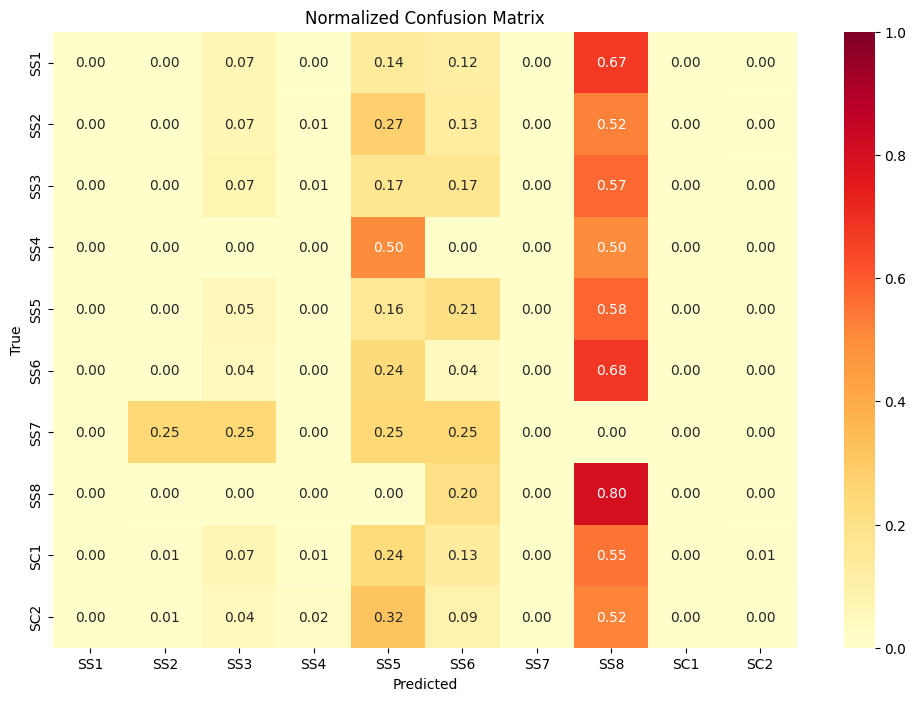

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/testing_result_1.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==1]
print(df)

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

   epoch average validation loss  \
0      2    [0.7309179890830562]   

                                         true_labels  \
0  [0, 8, 1, 1, 8, 8, 8, 1, 8, 9, 8, 1, 1, 2, 8, ...   

                                         predictions  \
0  [5, 7, 4, 4, 5, 7, 4, 7, 7, 7, 7, 4, 7, 7, 5, ...   

                                    falseProbability  \
0  [-0.20565038919448853, -0.0689404159784317, -0...   

                                     trueProbability       mcc        f1  \
0  [-0.03660770505666733, -0.02298998087644577, -... -0.003599  0.007388   

   precision   recall      acc  
0    0.00767  0.01864  0.01864  
Classification Report:
               precision    recall  f1-score   support

         SS1      0.000     0.000     0.000        43
         SS2      0.000     0.000     0.000       245
         SS3      0.091     0.071     0.080        70
         SS4      0.000     0.000     0.000         6
         SS5      0.013     0.158     0.024        19
         SS6      0.

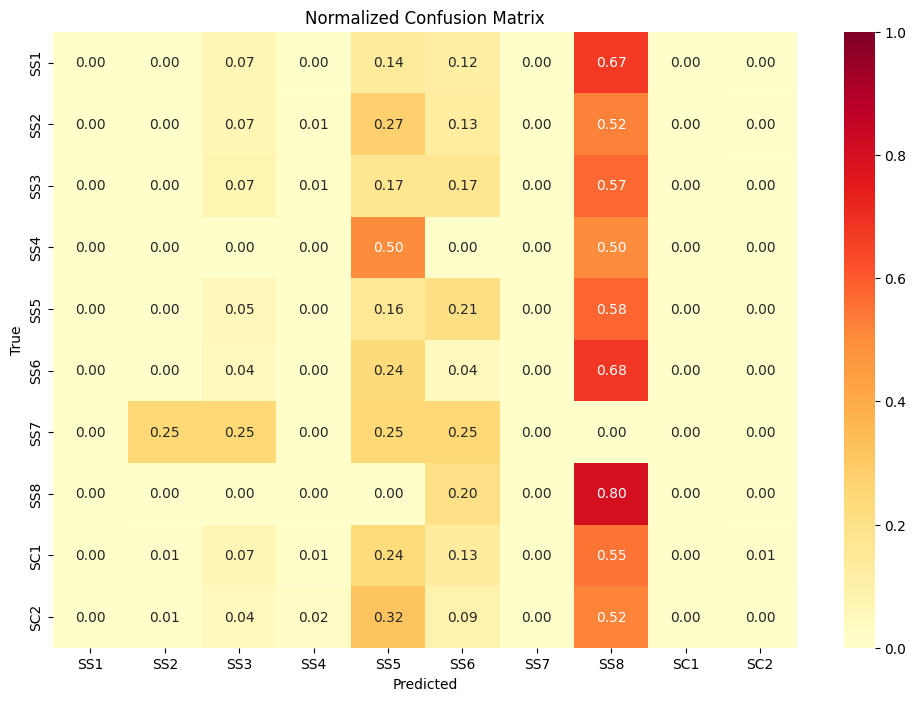

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Load the data
data = pd.read_pickle('/content/drive/MyDrive/AIED25/M4_Audibert/testing_result_2.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==2]
print(df)

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))

# Binarize the predicted labels for multi-class classification
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))
# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Plot the normalized confusion matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()